# PetroVision – Model 1 (V2)

# Step 0: Setup

# Step 0.1: Imports libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)

Mounted at /content/drive


# Step 0.2: Load df & cleaning

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Dataset/Dataset_plus5_2years_45stations_REALISTIC_SA_PRODUCTION_FINAL_B.csv"
TARGET = "performance_score"

df = pd.read_csv(DATA_PATH)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Stations:", df["station_id"].nunique())
print("Years:", sorted(df["date"].astype(str).str[:4].unique()))

Rows: 90000
Columns: 51
Stations: 45
Years: ['2024', '2025']


# Step 1: Helper Functions

In [ ]:
# Step 2: Evaluation & Visualization Helpers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
all_summaries = []

# =============================
# Metrics Summary Table
# =============================
def build_metrics_summary(tag, y_true, y_pred, n_train, n_test, n_features):
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    resid = y_true - y_pred

    summary = pd.DataFrame([{
        "Split": tag,
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2": round(r2, 4),
        "Mean Residual": round(np.mean(resid), 4),
        "Median |Residual|": round(np.median(np.abs(resid)), 4),
        "% |Error| > 10": round(np.mean(np.abs(resid) > 10) * 100, 2),
        "Train Size": n_train,
        "Test Size": n_test,
        "Features": n_features
    }])

    return summary


# =============================
# Feature Importance
# =============================
def plot_feature_importance(model, top_n=20, title="Feature Importance (Gain)"):
    score = model.get_score(importance_type="gain")
    if not score:
        print("No feature importance available.")
        return

    imp = pd.DataFrame({
        "feature": list(score.keys()),
        "gain": list(score.values())
    }).sort_values("gain", ascending=False).head(top_n)

    plt.figure(figsize=(8, 6))
    plt.barh(imp["feature"][::-1], imp["gain"][::-1])
    plt.title(title)
    plt.xlabel("Gain")
    plt.tight_layout()
    plt.show()


# =============================
# Residual Plots
# =============================
def plot_residuals(y_true, y_pred, title="Residual Analysis"):
    resid = y_true - y_pred

    plt.figure(figsize=(6, 4))
    plt.hist(resid, bins=40)
    plt.title(title + " - Histogram")
    plt.xlabel("Residual")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.scatter(y_pred, resid, s=6, alpha=0.5)
    plt.axhline(0)
    plt.title(title + " - Residuals vs Prediction")
    plt.xlabel("Prediction")
    plt.ylabel("Residual")
    plt.tight_layout()
    plt.show()


# =============================
# Boxplot Errors
# =============================
def plot_boxplot_errors(y_true, y_pred, title="Absolute Error Boxplot"):
    abs_err = np.abs(y_true - y_pred)

    plt.figure(figsize=(5, 4))
    plt.boxplot(abs_err, vert=True)
    plt.title(title)
    plt.ylabel("|Error|")
    plt.tight_layout()
    plt.show()


# =============================
# Outliers Table
# =============================
def get_outliers_df(test_df, y_true, y_pred, top_n=20):
    out = test_df.copy()
    out["_y_true"] = y_true
    out["_y_pred"] = y_pred
    out["_abs_err"] = np.abs(out["_y_true"] - out["_y_pred"])
    return out.sort_values("_abs_err", ascending=False).head(top_n)


# =============================
# SHAP Summary
# =============================
def plot_shap_summary(model, X_sample, title="SHAP Summary"):
    import shap
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)

    shap.summary_plot(shap_values, X_sample, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Step 3: Basic Preprocessing

# Step 3.1: Basic Preprocessing + Consistency Fixes

In [ ]:
# Convert date
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Extract time features
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek

# Quick check
print("Null dates:", df["date"].isna().sum())
print("Unique years:", sorted(df["year"].unique()))


# 1) Normalize shutdown_type values to only: full / partial / NaN
if "shutdown_type" in df.columns:
    df["shutdown_type"] = df["shutdown_type"].astype(str).str.strip().str.lower()
    df.loc[df["shutdown_type"].isin(["nan", "none", "0", ""] ), "shutdown_type"] = np.nan
    df.loc[(df["is_shutdown"] == 1) & (~df["shutdown_type"].isin(["full", "partial"])), "shutdown_type"] = "partial"
else:
    df["shutdown_type"] = np.nan

# 2) Force shutdown consistency
df.loc[df["is_shutdown"] == 0, ["shutdown_type", "shutdown_reason"]] = np.nan

# 3) Fix invalid integers (examples)
int_cols = ["staff_count", "pumps_total", "pumps_working", "incidents_reported", "transactions",
            "complaints_count", "event_severity", "event_duration_minutes", "inventory_stockout"]
for c in int_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").round().fillna(0).astype(int)

# 4) Enforce pumps logic
if "pumps_total" in df.columns and "pumps_working" in df.columns:
    df["pumps_total"] = df["pumps_total"].clip(lower=1)
    df["pumps_working"] = df["pumps_working"].clip(lower=0)
    df["pumps_working"] = np.minimum(df["pumps_working"], df["pumps_total"])

    # Full shutdown => no working pumps
    df.loc[(df["is_shutdown"] == 1) & (df["shutdown_type"] == "full"), "pumps_working"] = 0

# 5) Enforce power outage => full shutdown + no sales
if "power_status" in df.columns:
    df["power_status"] = df["power_status"].astype(str).str.strip().str.lower()
    outage_mask = df["power_status"].isin(["outage", "power_outage", "blackout"])
    df.loc[outage_mask, "is_shutdown"] = 1
    df.loc[outage_mask, "shutdown_type"] = "full"

# 6) Enforce full shutdown => no transactions/volume/sales + queue=0
full_mask = (df["is_shutdown"] == 1) & (df["shutdown_type"] == "full")
for c in ["transactions", "fuel_volume", "total_sales"]:
    if c in df.columns:
        df.loc[full_mask, c] = 0
if "queue_time_avg" in df.columns:
    df.loc[full_mask, "queue_time_avg"] = 0

# 7) Fix stockout logic: stockout=1 => days_of_cover=0 + reduce sales/volume
if "inventory_stockout" in df.columns:
    stock_mask = df["inventory_stockout"] == 1
    if "inventory_days_of_cover" in df.columns:
        df.loc[stock_mask, "inventory_days_of_cover"] = 0

    # Apply soft reduction (do not zero everything unless full shutdown)
    for c in ["transactions", "fuel_volume", "total_sales"]:
      if c in df.columns:
        if c == "transactions":
            df.loc[stock_mask & ~full_mask, c] = (
                df.loc[stock_mask & ~full_mask, c] * 0.60
            ).round().astype(int)
        else:
            df.loc[stock_mask & ~full_mask, c] = (
                df.loc[stock_mask & ~full_mask, c].astype(float) * 0.60
            )

# 8) Make sure performance_score is bounded only (NO upgrades here)
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce").fillna(0).clip(0, 100)

Null dates: 0
Unique years: [np.int32(2024), np.int32(2025)]


# Step 3.2 — Structured Noise


In [ ]:
import numpy as np

# Assumes df is already loaded + preprocessed
# and contains performance_score as the base target.

TARGET_BASE = "performance_score"
TARGET_OBS  = "performance_score_obs"

rng = np.random.default_rng(42)

# --- Helper masks ---
is_shutdown = df.get("is_shutdown", 0).fillna(0).astype(int)
shutdown_type = df.get("shutdown_type", "").fillna("").astype(str).str.lower()

full_mask = (is_shutdown == 1) & (shutdown_type == "full")
part_mask = (is_shutdown == 1) & (shutdown_type == "partial")

# --- Build difficulty index (0..1 approx), using available columns safely ---
def safe_z(x):
    x = np.asarray(x, dtype=float)
    if np.nanstd(x) < 1e-9:
        return np.zeros_like(x)
    return (x - np.nanmean(x)) / (np.nanstd(x) + 1e-9)

difficulty = np.zeros(len(df), dtype=float)

# More severe events -> higher difficulty
if "event_severity" in df.columns:
    sev = df["event_severity"].fillna(0).astype(float)
    difficulty += np.clip((sev - 1) / 3, 0, 1) * 0.35

# Longer event duration -> higher difficulty
if "event_duration_minutes" in df.columns:
    difficulty += np.clip(safe_z(df["event_duration_minutes"].fillna(0)), 0, 3) / 3 * 0.20

# Downtime -> higher difficulty
if "downtime_minutes" in df.columns:
    difficulty += np.clip(safe_z(df["downtime_minutes"].fillna(0)), 0, 3) / 3 * 0.25

# Low POS / network uptime -> higher difficulty
if "pos_uptime_pct" in df.columns:
    pos = df["pos_uptime_pct"].fillna(100).astype(float)
    difficulty += np.clip((95 - pos) / 30, 0, 1) * 0.18

if "network_uptime_pct" in df.columns:
    net = df["network_uptime_pct"].fillna(100).astype(float)
    difficulty += np.clip((95 - net) / 30, 0, 1) * 0.18

# Queues / complaints -> higher difficulty
if "queue_time_avg" in df.columns:
    difficulty += np.clip(safe_z(df["queue_time_avg"].fillna(0)), 0, 3) / 3 * 0.18

if "complaints_count" in df.columns:
    difficulty += np.clip(safe_z(df["complaints_count"].fillna(0)), 0, 3) / 3 * 0.20

# Stockout adds uncertainty (operations chaotic)
if "inventory_stockout" in df.columns:
    stock = df["inventory_stockout"].fillna(0).astype(int)
    difficulty += stock * 0.15

# Shutdown adds difficulty (partial less than full)
difficulty += part_mask.astype(float) * 0.25
difficulty += full_mask.astype(float) * 0.45

# Clamp difficulty
difficulty = np.clip(difficulty, 0, 1.5)

# --- Noise scale (in score points) ---
# Base sigma small, grows with difficulty.
sigma = 1.5 + (difficulty * 6.0)  # ~1.5..10.5

# Full shutdown should be more stable near zero (less random)
sigma[full_mask.values] = 1.0

# --- Apply noise ---
base = df[TARGET_BASE].astype(float).to_numpy()
noise = rng.normal(loc=0.0, scale=sigma, size=len(df))

score_obs = base + noise

# --- Enforce industrial floors/ceilings ---
# Full shutdown: keep very low
score_obs[full_mask.values] = np.clip(score_obs[full_mask.values], 0, 8)

# Partial shutdown: never zero (floor), but still low
# Choose a realistic floor range; adjust if you want.
partial_floor = 5
score_obs[part_mask.values] = np.clip(score_obs[part_mask.values], partial_floor, 55)

# Non-shutdown: normal clipping
normal_mask = ~(full_mask | part_mask)
score_obs[normal_mask.values] = np.clip(score_obs[normal_mask.values], 0, 100)

df[TARGET_OBS] = score_obs.round(1)

print("Created:", TARGET_OBS)
print("Obs target stats:", df[TARGET_OBS].describe())
print("Full shutdown obs min/max:", df.loc[full_mask, TARGET_OBS].min(), df.loc[full_mask, TARGET_OBS].max())
print("Partial shutdown obs min/max:", df.loc[part_mask, TARGET_OBS].min(), df.loc[part_mask, TARGET_OBS].max())

Created: performance_score_obs
Obs target stats: count    90000.000000
mean        76.211889
std         17.052732
min          0.000000
25%         74.100000
50%         80.900000
75%         85.200000
max         98.800000
Name: performance_score_obs, dtype: float64
Full shutdown obs min/max: 0.0 8.0
Partial shutdown obs min/max: 5.0 55.0


# Step 4: EDA (Exploratory Data Analysis)

# Step 4.1: Target distribution

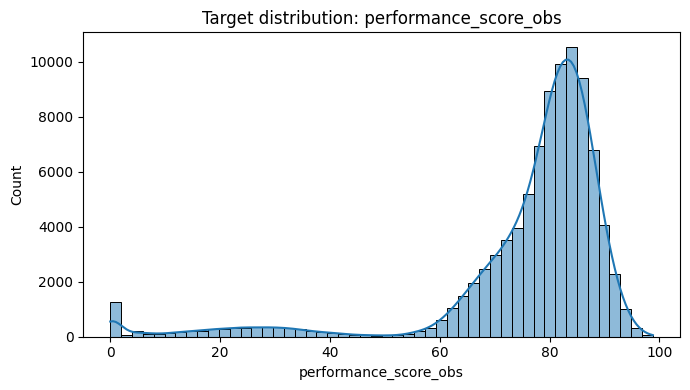

In [ ]:
import seaborn as sns

plt.figure(figsize=(7,4))
sns.histplot(df["performance_score_obs"], bins=50, kde=True)
plt.title("Target distribution: performance_score_obs")
plt.xlabel("performance_score_obs")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Step 4.2 — Boxplot (Outliers visualization)

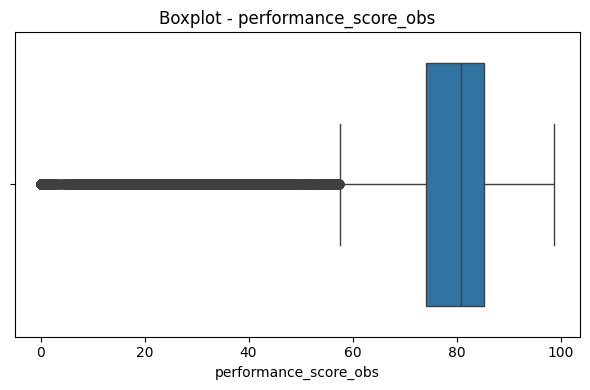

In [ ]:

plt.figure(figsize=(6,4))
sns.boxplot(x=df["performance_score_obs"])
plt.title("Boxplot - performance_score_obs")
plt.tight_layout()
plt.show()

# Step 4.3: Imbalance check (<40)

In [ ]:
total_cases = len(df)
low_cases = (df["performance_score_obs"] < 40).sum()
percentage_low = (low_cases / total_cases) * 100

print("Low performance cases (<40):", low_cases)
print("Percentage:", round(percentage_low, 2), "%")

Low performance cases (<40): 5605
Percentage: 6.23 %


# Step 4.4: Correlation heatmap

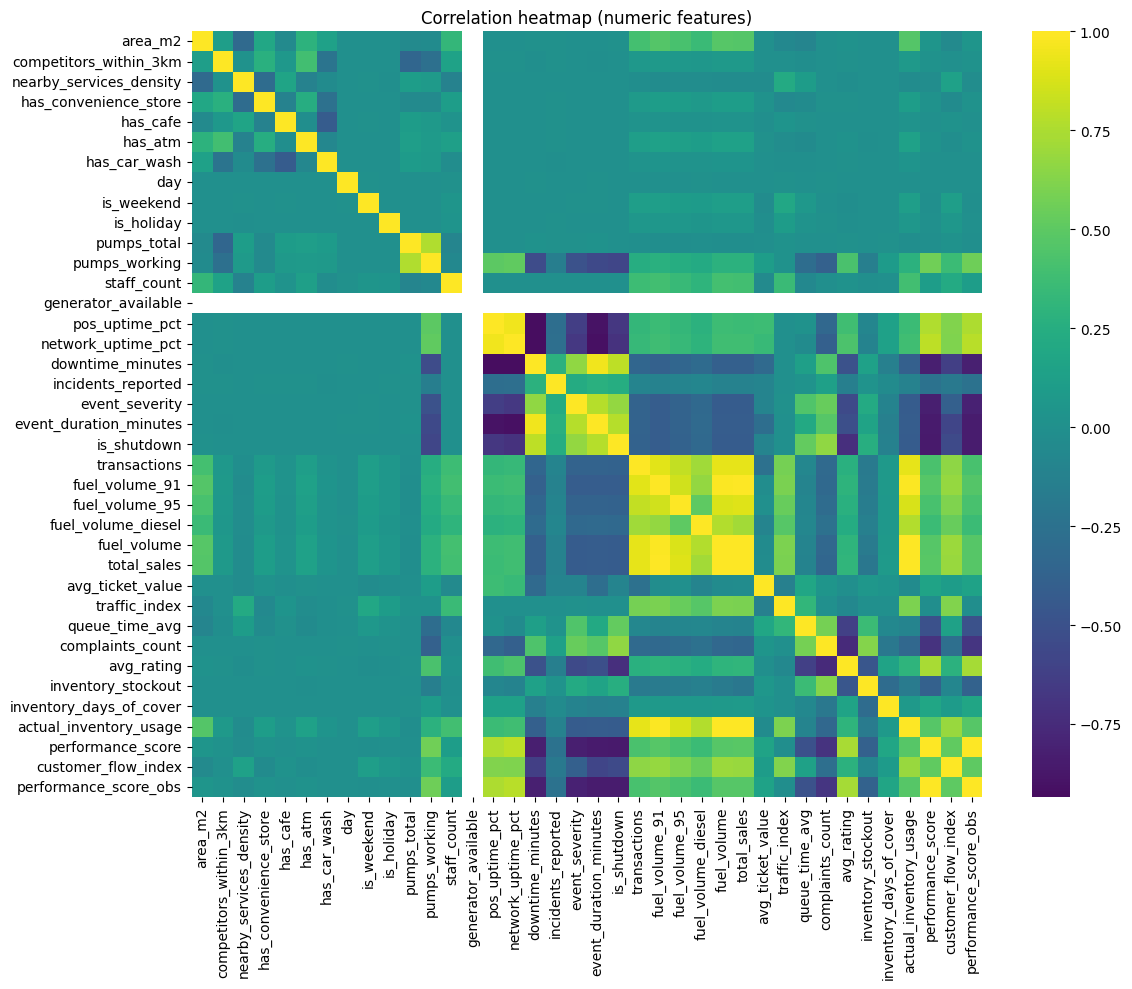

In [ ]:

numeric_cols = df.select_dtypes(include=["int64","float64"]).columns

plt.figure(figsize=(12,10))
corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    cmap="viridis",
    center=0,
    square=False,
    cbar=True
)

plt.title("Correlation heatmap (numeric features)")
plt.tight_layout()
plt.show()

# Step 4.5: Scatter examples

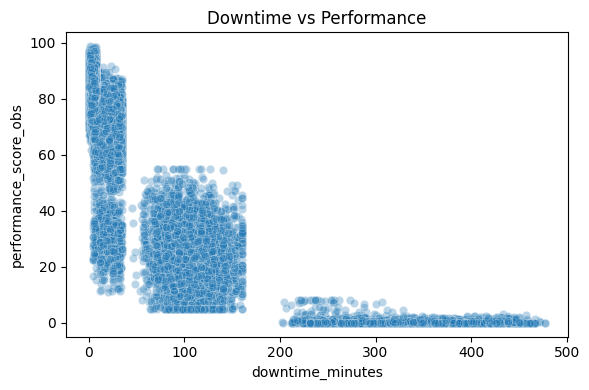

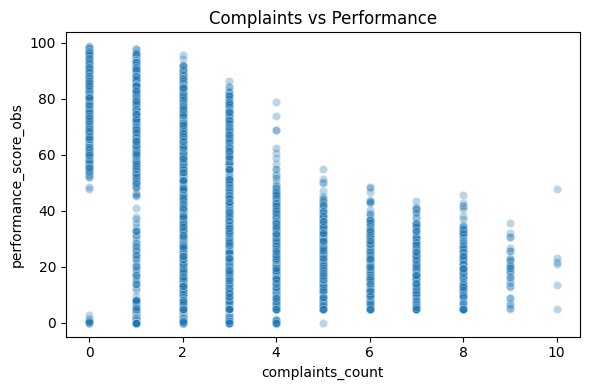

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=df["downtime_minutes"],
    y=df["performance_score_obs"],
    alpha=0.3
)
plt.title("Downtime vs Performance")
plt.tight_layout()
plt.show()


plt.figure(figsize=(6,4))
sns.scatterplot(
    x=df["complaints_count"],
    y=df["performance_score_obs"],
    alpha=0.3
)
plt.title("Complaints vs Performance")
plt.tight_layout()
plt.show()

# Step 5: Station Holdout



## Step 5.1 — Split by Station

In [ ]:
import numpy as np
np.random.seed(42)

stations = df["station_id"].unique()
np.random.shuffle(stations)

split_point = int(len(stations) * 0.2)

test_stations = stations[:split_point]
train_stations = stations[split_point:]

train_df = df[df["station_id"].isin(train_stations)].copy()
test_df  = df[df["station_id"].isin(test_stations)].copy()

print("Train stations:", len(train_stations))
print("Test stations:", len(test_stations))
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

Train stations: 36
Test stations: 9
Train rows: 71883
Test rows: 18117


## Step 5.2 — Build X/Y

In [ ]:
TARGET = "performance_score_obs"

drop_cols = [
    "performance_score_obs",
    "performance_score",
    "date",
    "shutdown_reason"
]

y_train = train_df[TARGET].values
y_test  = test_df[TARGET].values

X_train = train_df.drop(columns=drop_cols, errors="ignore")
X_test  = test_df.drop(columns=drop_cols, errors="ignore")

X_train = pd.get_dummies(X_train)
X_test  = pd.get_dummies(X_test)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (71883, 116)
X_test shape: (18117, 116)


## Step 5.3 — Train + Evaluate

,Split,MAE,RMSE,R2,Mean Residual,Median |Residual|,% |Error| > 10,Train Size,Test Size,Features
0,Station Holdout,3.4532,4.5236,0.9296,0.0329,2.776,3.03,71883,18117,116


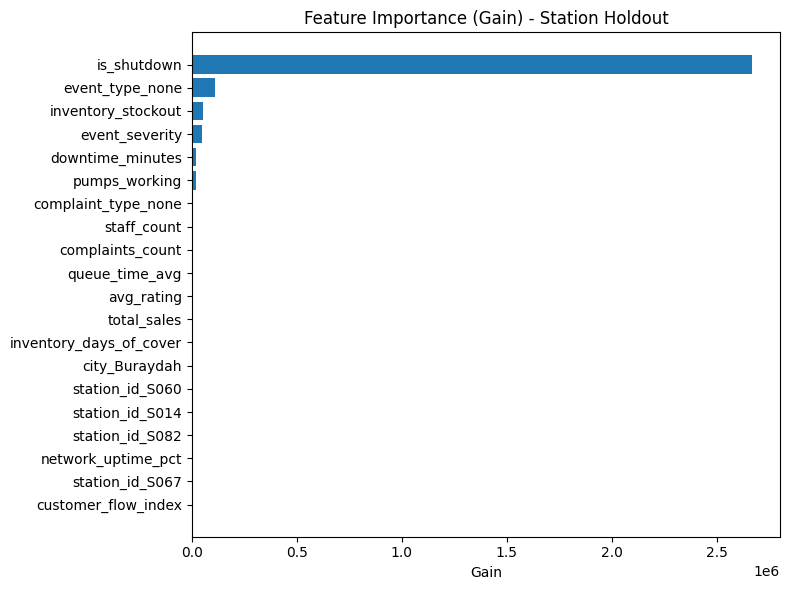

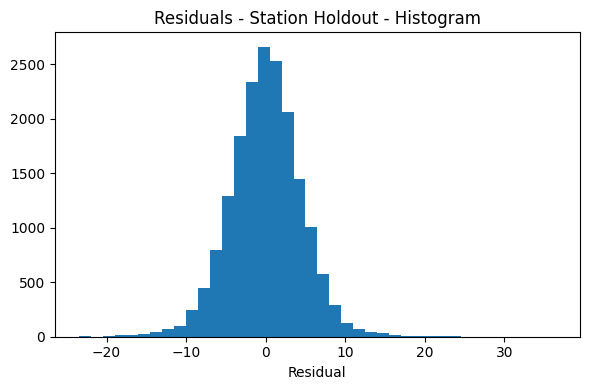

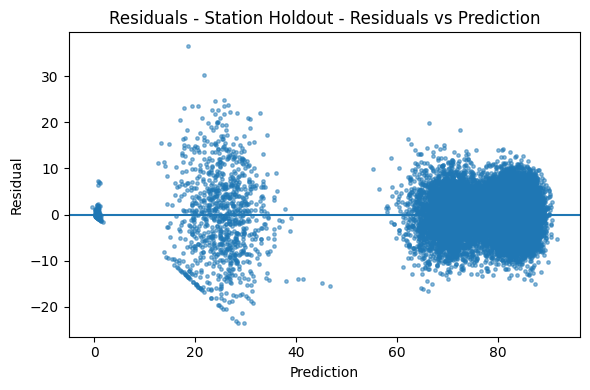

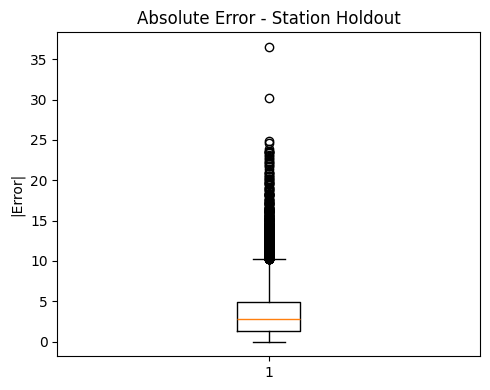

,station_id,city,station_type,area_m2,competitors_within_3km,nearby_services_density,has_convenience_store,has_cafe,has_atm,has_car_wash,...,inventory_stockout,inventory_days_of_cover,actual_inventory_usage,performance_score,day_of_week,customer_flow_index,performance_score_obs,_y_true,_y_pred,_abs_err
70218,S085,Makkah,Urban,1828,5,5.32,0,1,1,0,...,0,1.9,181.10,27.853195,0,0.73,55.0,55.0,18.495483,36.504517
19162,S017,Madinah,Neighborhood,1395,2,4.06,1,1,0,0,...,0,5.0,181.25,30.281698,0,0.77,51.9,51.9,21.669941,30.230059
80869,S041,Dammam,Urban,1252,4,7.99,1,0,1,0,...,0,0.0,83.23,29.182631,2,0.62,50.6,50.6,25.686556,24.913444
85636,S053,Jeddah,Urban,2020,10,3.72,1,0,1,0,...,0,6.4,361.47,24.668789,4,1.02,48.6,48.6,23.938633,24.661367
66525,S053,Jeddah,Urban,2020,10,3.72,1,0,1,0,...,0,8.1,266.86,33.408102,6,0.62,50.4,50.4,26.545891,23.854109
7331,S085,Makkah,Urban,1828,5,5.32,0,1,1,0,...,0,5.1,121.67,23.642563,2,0.60,49.2,49.2,25.640690,23.559310
2997,S036,Taif,Urban,2314,5,4.24,1,0,1,1,...,0,3.3,206.32,18.277281,3,0.67,42.8,42.8,19.286757,23.513243
11712,S053,Jeddah,Urban,2020,10,3.72,1,0,1,0,...,0,6.5,280.37,24.040699,5,0.80,44.1,44.1,20.597727,23.502273
2419,S057,Najran,Neighborhood,1652,7,4.15,1,1,1,0,...,0,5.4,64.42,27.714714,1,0.59,6.3,6.3,29.792372,23.492372
19130,S036,Taif,Urban,2314,5,4.24,1,0,1,1,...,0,7.0,428.32,26.798991,6,0.94,5.0,5.0,28.429855,23.429855


/tmp/ipython-input-1236/3234116053.py:114: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, show=False)


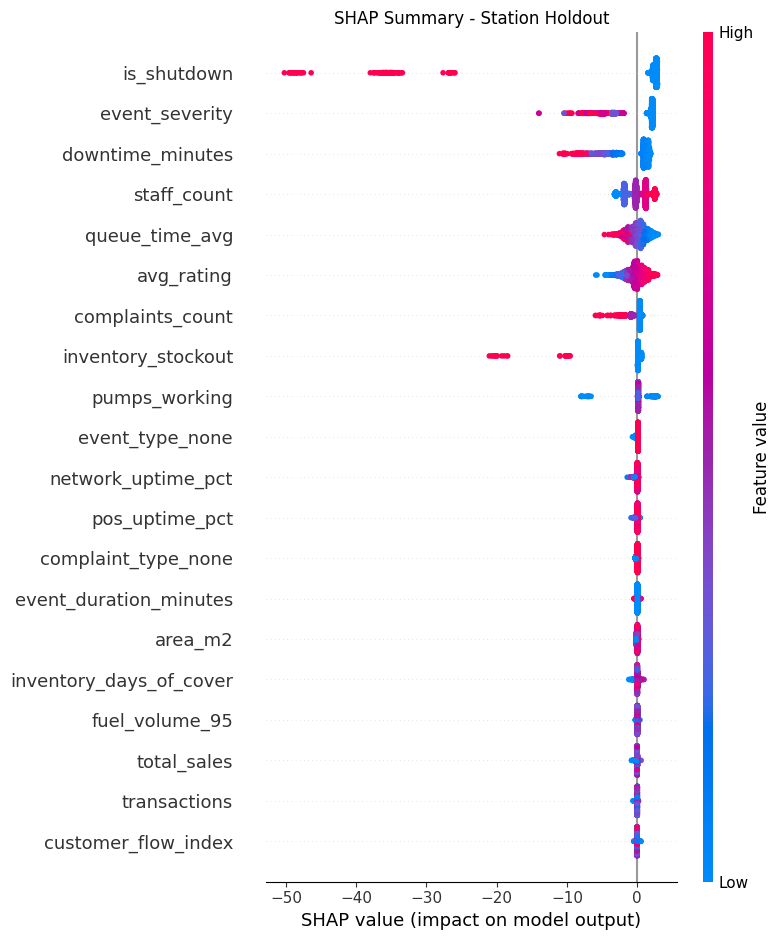

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test, label=y_test)

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.05,
    "max_depth": 6,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "seed": 42
}

model = xgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    evals=[(dtest, "test")],
    early_stopping_rounds=100,
    verbose_eval=False
)

# Predictions
y_pred = model.predict(dtest)

# Metrics
tag = "Station Holdout"

summary_row = build_metrics_summary(
    tag=tag,
    y_true=y_test,
    y_pred=y_pred,
    n_train=len(train_df),
    n_test=len(test_df),
    n_features=X_train.shape[1]
)
all_summaries.append(summary_row)
display(summary_row)

plot_feature_importance(model, top_n=20, title=f"Feature Importance (Gain) - {tag}")
plot_residuals(y_test, y_pred, title=f"Residuals - {tag}")
plot_boxplot_errors(y_test, y_pred, title=f"Absolute Error - {tag}")

outliers_df = get_outliers_df(test_df, y_test, y_pred, top_n=20)
display(outliers_df)

X_sample = X_test.sample(min(2000, len(X_test)), random_state=42)
plot_shap_summary(model, X_sample, title=f"SHAP Summary - {tag}")

# Step 6: Year Holdout (Train 2024 -> Test 2025)

In [ ]:
# =========================
# Year Holdout Split (Train 2024 -> Test 2025)
# =========================
if "year" not in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["year"] = df["date"].dt.year

train_df = df[df["year"] == 2024].copy()
test_df  = df[df["year"] == 2025].copy()

print("Train rows:", len(train_df), "Test rows:", len(test_df))
print("Train stations:", train_df["station_id"].nunique(), "Test stations:", test_df["station_id"].nunique())

Train rows: 45063 Test rows: 44937
Train stations: 45 Test stations: 45


## Step 6.1: Prepare X/y with strict leakage drops

In [ ]:
# =========================
# Target + Leakage Drops
# =========================

TARGET = "performance_score_obs" if "performance_score_obs" in df.columns else "performance_score"
print("Using TARGET:", TARGET)

LEAK_LIKE_COLS = [
    "is_shutdown",
    "event_duration_minutes",
    "downtime_minutes",
    "event_severity",
    "complaints_count",
    "queue_time_avg",
    "pos_uptime_pct",
    "network_uptime_pct",
]

drop_cols = [
    TARGET,
    "performance_score",
    "date",
    "shutdown_reason"
] + LEAK_LIKE_COLS

y_train = train_df[TARGET].values
y_test  = test_df[TARGET].values

X_train = train_df.drop(columns=drop_cols, errors="ignore")
X_test  = test_df.drop(columns=drop_cols, errors="ignore")

X_train = pd.get_dummies(X_train)
X_test  = pd.get_dummies(X_test)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Using TARGET: performance_score_obs
X_train shape: (45063, 119)
X_test shape: (44937, 119)


## Step 6.2: Train + Evaluate (Year Holdout)


,Split,MAE,RMSE,R2,Mean Residual,Median |Residual|,% |Error| > 10,Train Size,Test Size,Features
0,Year Holdout,3.7497,4.9518,0.9161,0.0148,2.985,4.58,45063,44937,119


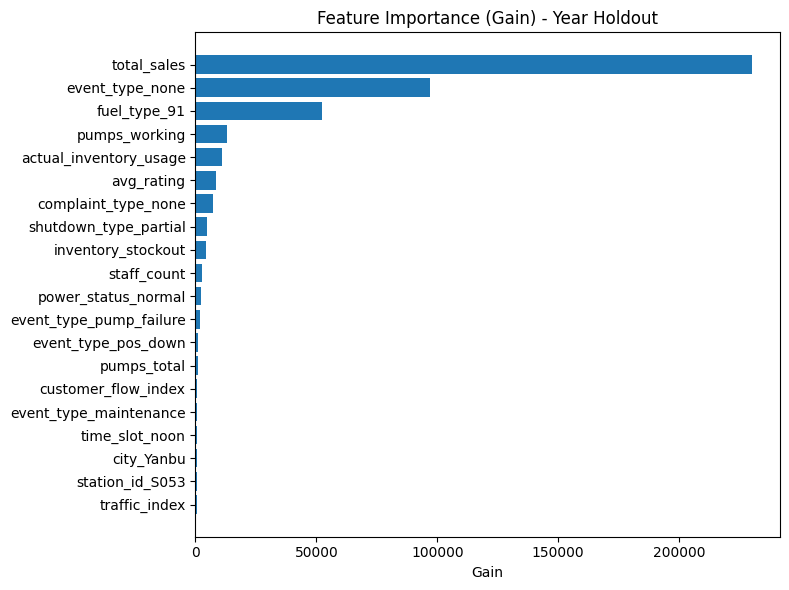

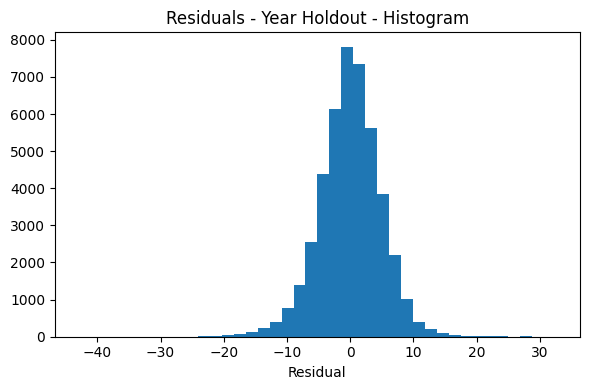

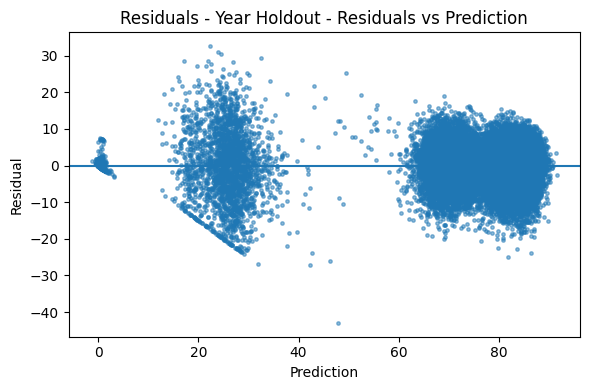

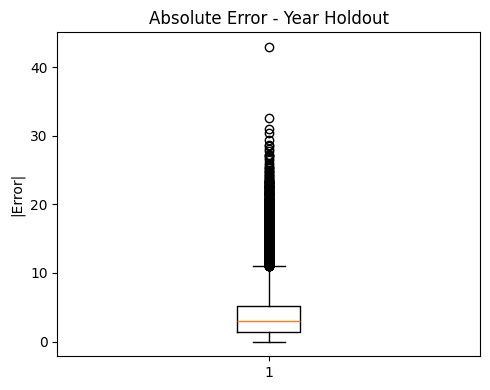

,station_id,city,station_type,area_m2,competitors_within_3km,nearby_services_density,has_convenience_store,has_cafe,has_atm,has_car_wash,...,inventory_stockout,inventory_days_of_cover,actual_inventory_usage,performance_score,day_of_week,customer_flow_index,performance_score_obs,_y_true,_y_pred,_abs_err
67524,S085,Makkah,Urban,1828,5,5.32,0,1,1,0,...,0,4.1,138.700000,23.943232,2,0.61,5.0,5.0,47.945030,42.945030
71359,S073,Madinah,Urban,2626,7,5.02,0,1,1,1,...,0,6.6,181.670000,22.414221,0,0.67,55.0,55.0,22.430470,32.569530
87939,S078,Yanbu,Urban,1820,3,6.33,1,1,1,0,...,0,5.3,206.810000,34.638366,5,1.01,55.0,55.0,23.950274,31.049726
70218,S085,Makkah,Urban,1828,5,5.32,0,1,1,0,...,0,1.9,181.100000,27.853195,0,0.73,55.0,55.0,24.515800,30.484200
66812,S041,Dammam,Urban,1252,4,7.99,1,0,1,0,...,0,1.1,519.920000,55.216393,1,0.91,61.9,61.9,32.452183,29.447817
80869,S041,Dammam,Urban,1252,4,7.99,1,0,1,0,...,0,0.0,83.230000,29.182631,2,0.62,50.6,50.6,21.995043,28.604957
3744,S078,Yanbu,Urban,1820,3,6.33,1,1,1,0,...,1,0.0,116.731980,16.374012,5,0.65,45.6,45.6,17.098251,28.501749
59853,S014,Dammam,Highway,1697,2,5.91,0,1,0,0,...,0,2.7,227.750000,35.264677,4,0.75,55.0,55.0,26.884701,28.115299
56594,S036,Taif,Urban,2314,5,4.24,1,0,1,1,...,0,4.5,371.630000,26.016902,4,0.83,50.3,50.3,22.496561,27.803439
4195,S016,Madinah,Neighborhood,1189,7,4.62,1,1,1,0,...,0,4.5,242.700000,22.875923,4,0.87,15.1,15.1,42.362671,27.262671


/tmp/ipython-input-1236/3234116053.py:114: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, show=False)


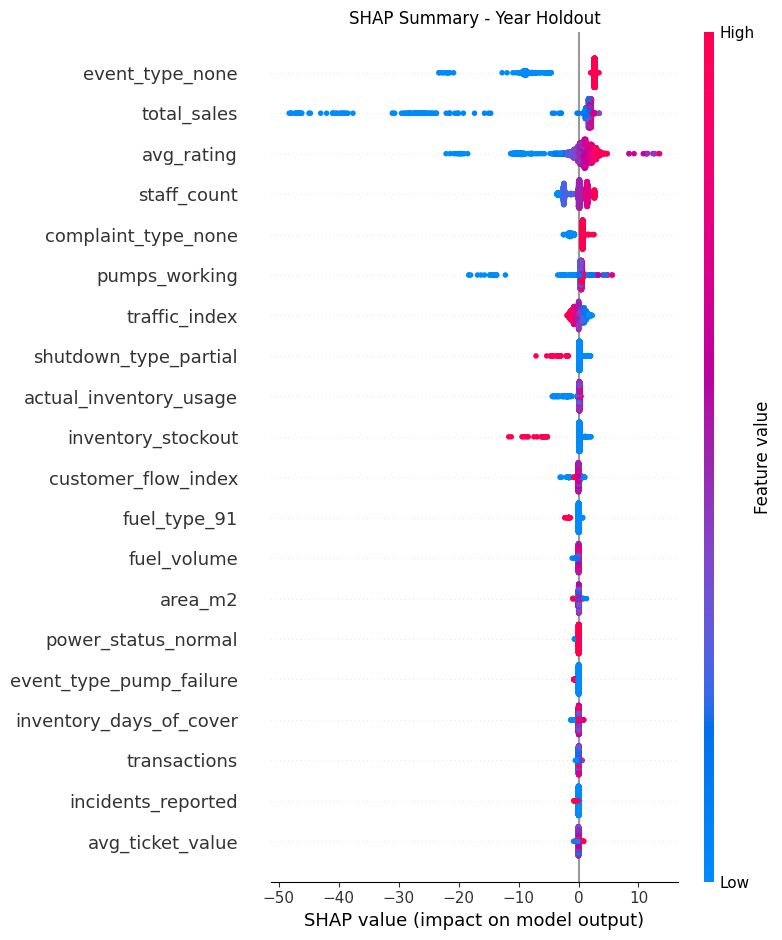

In [ ]:
# =========================
# Train + Evaluate (same style as Station code)
# =========================

import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test, label=y_test)

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.05,
    "max_depth": 6,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "seed": 42
}

model = xgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    evals=[(dtest, "test")],
    early_stopping_rounds=100,
    verbose_eval=False
)

# Predictions
y_pred = model.predict(dtest)

# Metrics + Visuals (same exact block)
tag = "Year Holdout"

summary_row = build_metrics_summary(
    tag=tag,
    y_true=y_test,
    y_pred=y_pred,
    n_train=len(train_df),
    n_test=len(test_df),
    n_features=X_train.shape[1]
)
all_summaries.append(summary_row)
display(summary_row)

plot_feature_importance(model, top_n=20, title=f"Feature Importance (Gain) - {tag}")
plot_residuals(y_test, y_pred, title=f"Residuals - {tag}")
plot_boxplot_errors(y_test, y_pred, title=f"Absolute Error - {tag}")

outliers_df = get_outliers_df(test_df, y_test, y_pred, top_n=20)
display(outliers_df)

X_sample = X_test.sample(min(2000, len(X_test)), random_state=42)
plot_shap_summary(model, X_sample, title=f"SHAP Summary - {tag}")

# Step 7: Stations + Time Combined Split

## Step 7.1: Station + Time Combined Split (create train_df / test_df)

In [ ]:
# =========================
# Station + Time Combined Split (Stress Test)
# =========================

import numpy as np
import pandas as pd
SEED = 42
rng = np.random.default_rng(SEED)

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["station_id"] = df["station_id"].astype(str)

stations = df["station_id"].unique()
rng.shuffle(stations)

n_test = max(1, int(len(stations) * 0.20))
test_stations = set(stations[:n_test])

start_date = pd.Timestamp("2025-10-01")
end_date   = pd.Timestamp("2025-12-31")

time_mask = (df["date"] >= start_date) & (df["date"] <= end_date)
station_mask = df["station_id"].isin(test_stations)

test_mask = station_mask & time_mask

train_df = df.loc[~test_mask].copy()
test_df  = df.loc[test_mask].copy()

print("SPLIT: STATION+TIME_COMBINED")
print("Test stations:", len(test_stations))
print("Time window:", start_date.date(), "to", end_date.date())
print("Train rows:", len(train_df), "| Test rows:", len(test_df))
print("Train stations:", train_df["station_id"].nunique(), "| Test stations in test:", test_df["station_id"].nunique())

assert len(test_df) > 0, "Test set is empty. Change time window or station fraction."

SPLIT: STATION+TIME_COMBINED
Test stations: 9
Time window: 2025-10-01 to 2025-12-31
Train rows: 87741 | Test rows: 2259
Train stations: 45 | Test stations in test: 9


## Step 7.2: Station + Time Combined Split


Using TARGET: performance_score_obs
X_train shape: (87741, 119)
X_test shape: (2259, 119)


,Split,MAE,RMSE,R2,Mean Residual,Median |Residual|,% |Error| > 10,Train Size,Test Size,Features
0,Station + Time Holdout,3.8087,5.065,0.9175,-0.0775,3.0134,4.96,87741,2259,119


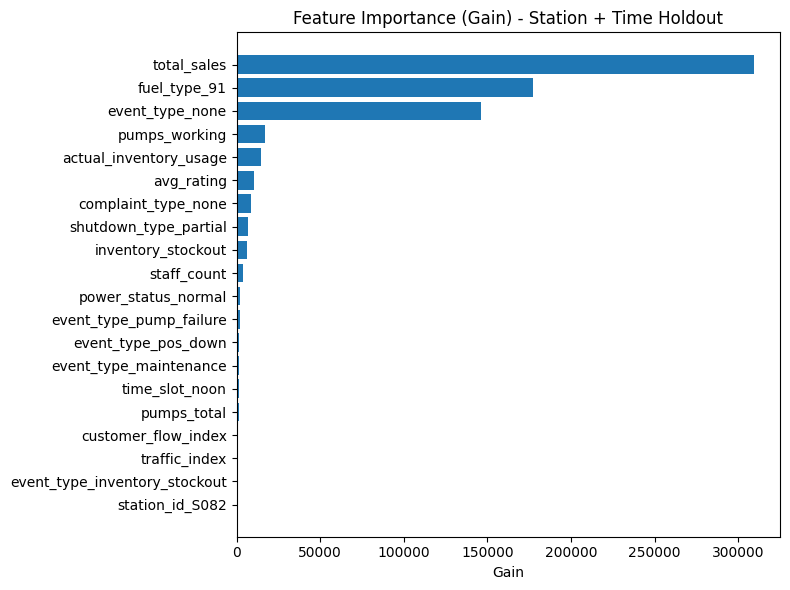

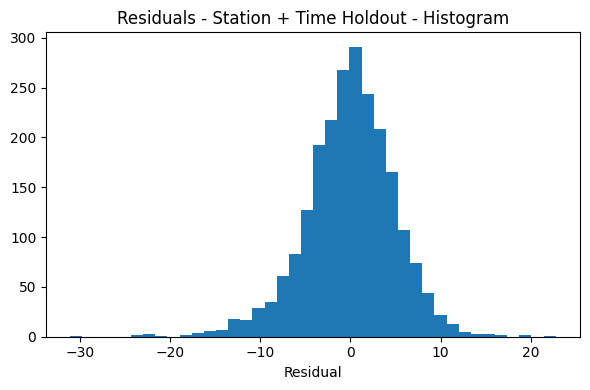

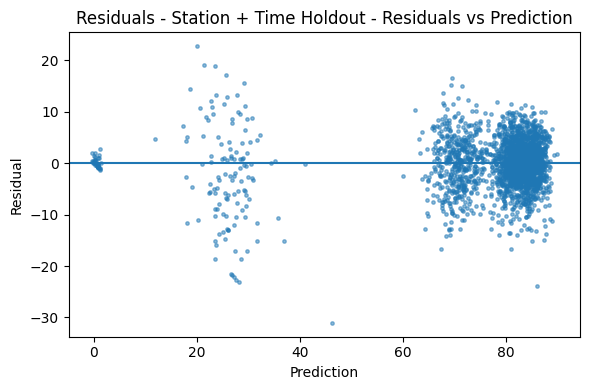

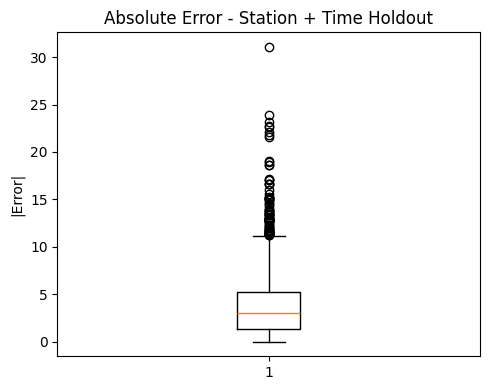

,station_id,city,station_type,area_m2,competitors_within_3km,nearby_services_density,has_convenience_store,has_cafe,has_atm,has_car_wash,...,inventory_stockout,inventory_days_of_cover,actual_inventory_usage,performance_score,day_of_week,customer_flow_index,performance_score_obs,_y_true,_y_pred,_abs_err
4195,S016,Madinah,Neighborhood,1189,7,4.62,1,1,1,0,...,0,4.5,242.700000,22.875923,4,0.87,15.1,15.1,46.165806,31.065806
50218,S065,Hail,Neighborhood,1789,6,6.17,0,0,1,1,...,0,3.4,1229.560000,63.786059,1,1.13,62.3,62.3,86.154449,23.854449
75039,S009,Dammam,Highway,1745,2,2.09,0,0,0,0,...,0,6.4,187.390000,18.277127,6,0.82,5.0,5.0,28.132574,23.132574
33940,S082,Riyadh,Urban,1926,5,6.74,1,0,1,1,...,1,0.0,235.807396,18.480536,5,0.91,42.7,42.7,19.929787,22.770213
29597,S082,Riyadh,Urban,1926,5,6.74,1,0,1,1,...,0,5.5,258.700000,18.346190,6,0.86,5.0,5.0,27.649643,22.649643
42229,S017,Madinah,Neighborhood,1395,2,4.06,1,1,0,0,...,0,7.3,119.490000,24.786605,6,0.62,5.0,5.0,27.130978,22.130978
7815,S067,Jeddah,Highway,2230,2,1.63,1,0,1,1,...,0,3.4,486.280000,21.679075,3,0.91,5.0,5.0,26.790220,21.790220
20516,S049,Jeddah,Urban,1074,4,4.59,1,1,1,0,...,0,1.4,136.710000,19.018959,6,0.64,5.0,5.0,26.617846,21.617846
13935,S049,Jeddah,Urban,1074,4,4.59,1,1,1,0,...,0,0.9,149.530000,26.104998,2,0.81,40.4,40.4,21.343077,19.056923
15673,S054,Riyadh,Neighborhood,2292,6,5.46,1,1,1,0,...,0,2.6,637.870000,31.309072,5,0.81,42.5,42.5,23.586233,18.913767


/tmp/ipython-input-1236/3234116053.py:114: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, show=False)


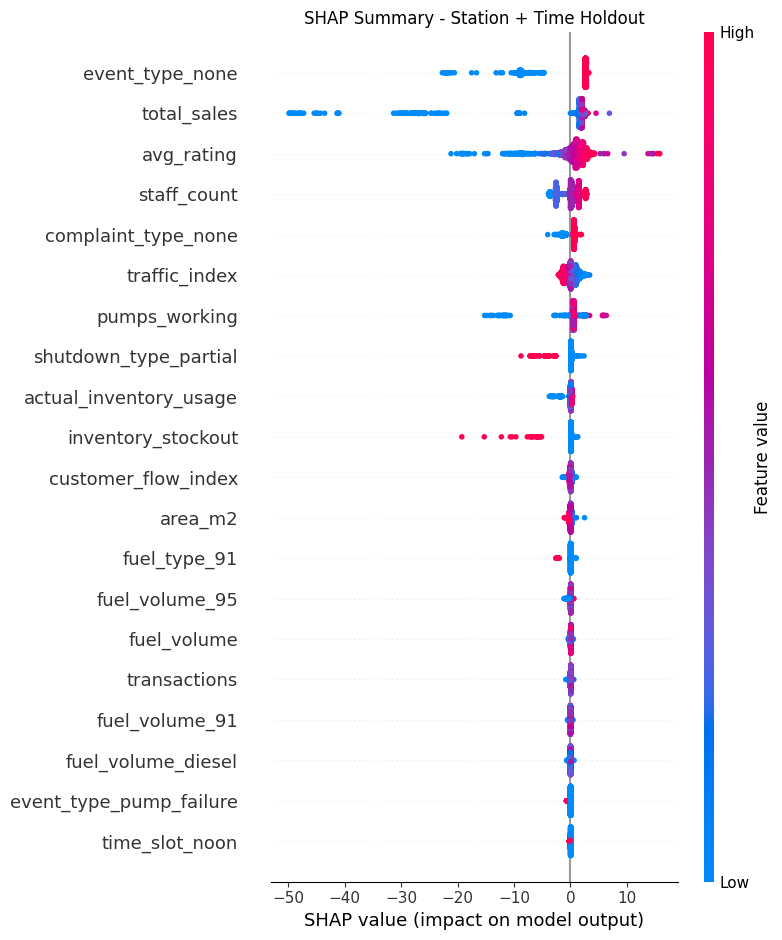

In [ ]:
# =========================
# Target + Leakage Drops (same style as Station/Year)
# =========================

import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

TARGET = "performance_score_obs" if "performance_score_obs" in df.columns else "performance_score"
print("Using TARGET:", TARGET)

LEAK_LIKE_COLS = [
    "is_shutdown",
    "event_duration_minutes",
    "downtime_minutes",
    "event_severity",
    "complaints_count",
    "queue_time_avg",
    "pos_uptime_pct",
    "network_uptime_pct",
]

drop_cols = [TARGET, "performance_score", "date", "shutdown_reason"] + LEAK_LIKE_COLS

y_train = train_df[TARGET].values
y_test  = test_df[TARGET].values

X_train = train_df.drop(columns=drop_cols, errors="ignore")
X_test  = test_df.drop(columns=drop_cols, errors="ignore")

X_train = pd.get_dummies(X_train)
X_test  = pd.get_dummies(X_test)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# =========================
# Train + Evaluate (same style as Station/Year)
# =========================

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test, label=y_test)

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.05,
    "max_depth": 6,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "seed": 42
}

model = xgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    evals=[(dtest, "test")],
    early_stopping_rounds=100,
    verbose_eval=False
)

# Predictions
y_pred = model.predict(dtest)

# Metrics + Visuals (same block)
tag = "Station + Time Holdout"

summary_row = build_metrics_summary(
    tag=tag,
    y_true=y_test,
    y_pred=y_pred,
    n_train=len(train_df),
    n_test=len(test_df),
    n_features=X_train.shape[1]
)
all_summaries.append(summary_row)
display(summary_row)

plot_feature_importance(model, top_n=20, title=f"Feature Importance (Gain) - {tag}")
plot_residuals(y_test, y_pred, title=f"Residuals - {tag}")
plot_boxplot_errors(y_test, y_pred, title=f"Absolute Error - {tag}")

outliers_df = get_outliers_df(test_df, y_test, y_pred, top_n=20)
display(outliers_df)

X_sample = X_test.sample(min(2000, len(X_test)), random_state=42)
plot_shap_summary(model, X_sample, title=f"SHAP Summary - {tag}")

# Step 8: City Split


In [ ]:
# =========================
# Step 8.0: City Holdout Split
# =========================

import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
assert "city" in df.columns, "Missing column: city"
assert "date" in df.columns, "Missing column: date"

df["date"] = pd.to_datetime(df["date"], errors="coerce")

df["city"] = df["city"].astype(str).str.strip()
df.loc[df["city"].isin(["", "nan", "None"]), "city"] = np.nan

valid_cities = df["city"].dropna().unique()
assert len(valid_cities) > 1, "Need at least 2 valid cities for holdout."

rng = np.random.default_rng(42)
holdout_city = rng.choice(valid_cities)

train_df = df[df["city"] != holdout_city].copy()
test_df  = df[df["city"] == holdout_city].copy()

print("SPLIT: CITY_HOLDOUT")
print("Holdout city:", holdout_city)
print("Train rows:", len(train_df), "| Test rows:", len(test_df))
print("Train cities:", train_df["city"].nunique(), "| Test cities:", test_df["city"].nunique())
print("Train stations:", train_df["station_id"].nunique(), "| Test stations:", test_df["station_id"].nunique())

assert len(test_df) > 0, "Test set is empty. Pick a different holdout city."

SPLIT: CITY_HOLDOUT
Holdout city: Buraydah
Train rows: 88047 | Test rows: 1953
Train cities: 11 | Test cities: 1
Train stations: 44 | Test stations: 1


# Step 8.1: Train XGBoost on City Holdout split

X_train shape: (88047, 117)
X_test shape: (1953, 117)


,Split,MAE,RMSE,R2,Mean Residual,Median |Residual|,% |Error| > 10,Train Size,Test Size,Features
0,City Holdout (Buraydah),3.7502,5.0033,0.9013,-0.1302,2.9254,5.33,88047,1953,117


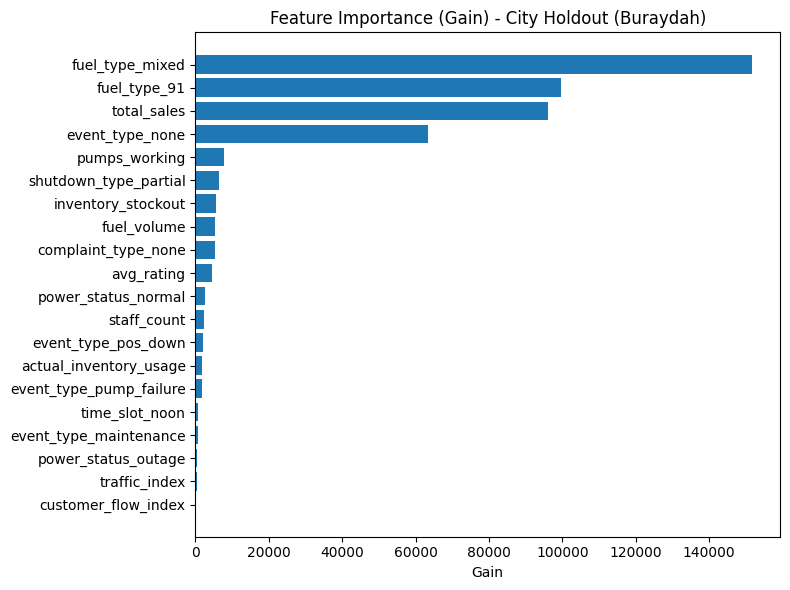

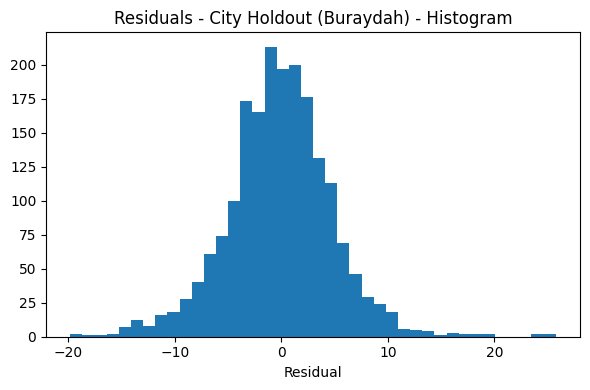

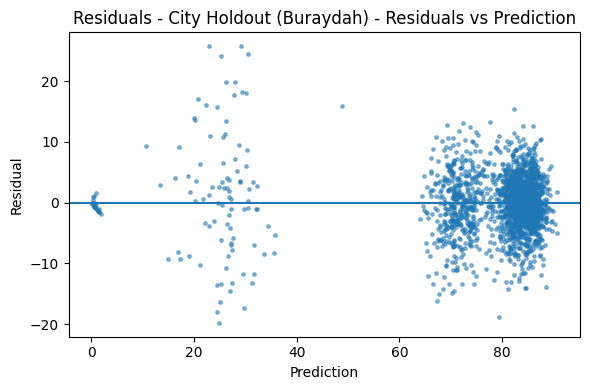

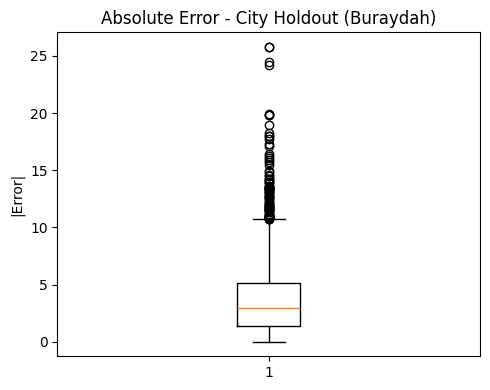

,station_id,city,station_type,area_m2,competitors_within_3km,nearby_services_density,has_convenience_store,has_cafe,has_atm,has_car_wash,...,inventory_stockout,inventory_days_of_cover,actual_inventory_usage,performance_score,day_of_week,customer_flow_index,performance_score_obs,_y_true,_y_pred,_abs_err
17415,S060,Buraydah,Urban,1564,7,3.16,1,0,1,1,...,0,4.9,270.600000,43.650113,2,0.76,55.0,55.0,29.231627,25.768373
80455,S060,Buraydah,Urban,1564,7,3.16,1,0,1,1,...,1,0.0,81.293986,13.575562,3,0.66,48.6,48.6,22.850271,25.749729
82808,S060,Buraydah,Urban,1564,7,3.16,1,0,1,1,...,0,3.3,119.650000,36.383099,3,0.66,55.0,55.0,30.517580,24.482420
86256,S060,Buraydah,Urban,1564,7,3.16,1,0,1,1,...,0,5.3,331.840000,21.617528,6,0.84,49.4,49.4,25.226437,24.173563
76230,S060,Buraydah,Urban,1564,7,3.16,1,0,1,1,...,0,4.1,328.480000,43.478765,2,0.87,48.0,48.0,28.056129,19.943871
28015,S060,Buraydah,Urban,1564,7,3.16,1,0,1,1,...,0,6.9,105.600000,31.388693,4,0.81,46.0,46.0,26.159330,19.840670
59298,S060,Buraydah,Urban,1564,7,3.16,1,0,1,1,...,0,5.3,139.130000,24.155372,4,0.87,5.0,5.0,24.800802,19.800802
38734,S060,Buraydah,Urban,1564,7,3.16,1,0,1,1,...,0,4.8,884.370000,60.989433,4,1.10,60.4,60.4,79.313660,18.913660
19990,S060,Buraydah,Urban,1564,7,3.16,1,0,1,1,...,0,5.6,138.580000,35.882357,4,0.70,47.7,47.7,29.453516,18.246484
25029,S060,Buraydah,Urban,1564,7,3.16,1,0,1,1,...,0,1.4,161.860000,22.894118,3,0.85,6.5,6.5,24.510847,18.010847


/tmp/ipython-input-1236/3234116053.py:114: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, show=False)


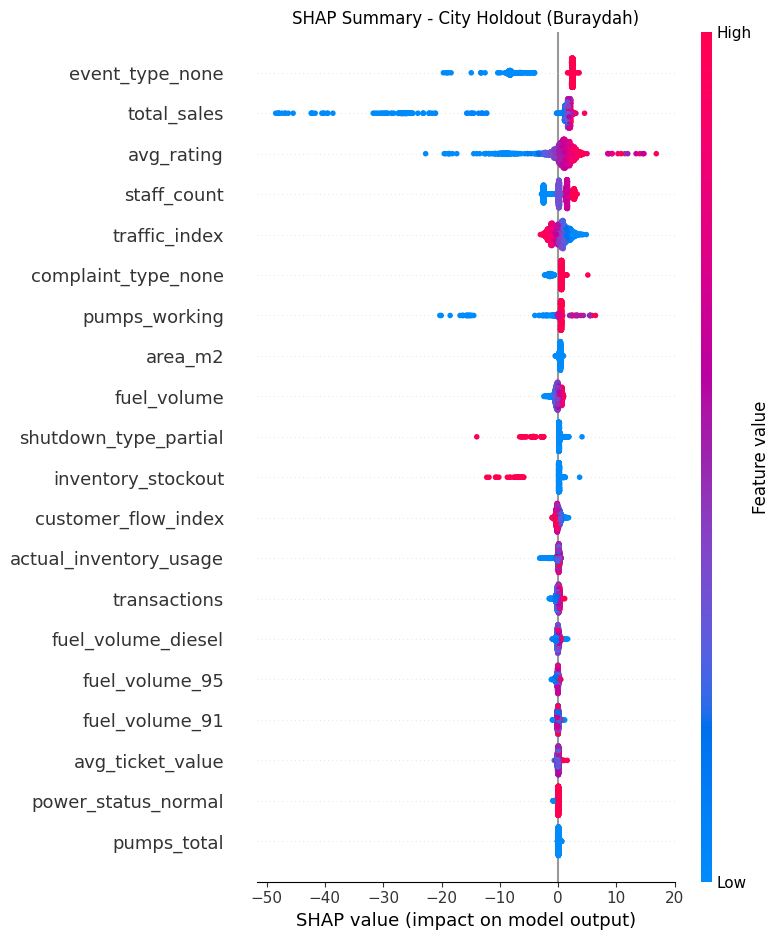

In [ ]:
# =========================
# Step 8.1: Build X/y (same pipeline style)
# =========================

X_train, X_test, y_train, y_test = build_xy(
    train_df,
    test_df,
    TARGET_COL,
    LEAK_LIKE_COLS
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# =========================
# Step 8.2: Train + Evaluate (same style as Station/Year)
# =========================

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test, label=y_test)

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.05,
    "max_depth": 6,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "seed": 42
}

model = xgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    evals=[(dtest, "test")],
    early_stopping_rounds=100,
    verbose_eval=False
)

# Predictions
y_pred = model.predict(dtest)

# Metrics + Visuals (same block)
tag = f"City Holdout ({holdout_city})"

summary_row = build_metrics_summary(
    tag=tag,
    y_true=y_test,
    y_pred=y_pred,
    n_train=len(train_df),
    n_test=len(test_df),
    n_features=X_train.shape[1]
)
all_summaries.append(summary_row)
display(summary_row)

plot_feature_importance(model, top_n=20, title=f"Feature Importance (Gain) - {tag}")
plot_residuals(y_test, y_pred, title=f"Residuals - {tag}")
plot_boxplot_errors(y_test, y_pred, title=f"Absolute Error - {tag}")

outliers_df = get_outliers_df(test_df, y_test, y_pred, top_n=20)
display(outliers_df)

X_sample = X_test.sample(min(2000, len(X_test)), random_state=42)
plot_shap_summary(model, X_sample, title=f"SHAP Summary - {tag}")

# Step 9: Model Validation & Generalization Summary


In [ ]:
import pandas as pd

dfc = comparison_df.copy()

station_best = (
    dfc[dfc["Split"].str.startswith("Station Holdout")]
    .sort_values(["R2", "RMSE"], ascending=[False, True])
    .head(1)
)

year_best = (
    dfc[dfc["Split"].str.startswith("Year Holdout")]
    .sort_values(["R2", "RMSE"], ascending=[False, True])
    .head(1)
)

station_time_best = (
    dfc[dfc["Split"].str.startswith("Station + Time Holdout")]
    .sort_values(["R2", "RMSE"], ascending=[False, True])
    .head(1)
)

city_best = (
    dfc[dfc["Split"].str.startswith("City Holdout")]
    .sort_values(["R2", "RMSE"], ascending=[False, True])
    .head(1)
)

comparison_df = pd.concat(all_summaries, ignore_index=True)

final_4 = comparison_df[[
    "Split","R2","MAE","RMSE","Mean Residual","Median |Residual|","% |Error| > 10",
    "Train Size","Test Size","Features"
]].copy()

display(final_4)

,Split,R2,MAE,RMSE,Mean Residual,Median |Residual|,% |Error| > 10,Train Size,Test Size,Features
0,Station Holdout,0.9296,3.4532,4.5236,0.0329,2.7760,3.03,71883,18117,116
1,Year Holdout,0.9161,3.7497,4.9518,0.0148,2.9850,4.58,45063,44937,119
2,Station + Time Holdout,0.9175,3.8087,5.0650,-0.0775,3.0134,4.96,87741,2259,119
3,City Holdout (Buraydah),0.9013,3.7502,5.0033,-0.1302,2.9254,5.33,88047,1953,117


# Generalization Analysis


The model maintains strong performance across multiple distribution shifts.
The highest R² (0.9296) is achieved in Station Holdout, while the most challenging scenario (City Holdout) still maintains R² above 0.90, indicating stable cross-city generalization.

# Robustness Conclusion

- No performance collapse observed

- No overfitting across time

- No extreme degradation under unseen station-time combination

- Error rate remains below 6% in all splits

# Step 10: EXPORTS (Models + Dashboard Artifacts)
 - Save XGBoost model
 - Save feature columns (critical for inference)
 - Save Global Drivers (Top features)
 - Train + Save Surrogate Model (Admin-friendly rules)
 - (Optional) Save demo predictions CSV

In [ ]:
all_summaries = []

In [ ]:
# =========================
#  Shared config
# =========================
import os, json, joblib
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.tree import DecisionTreeRegressor, export_text


EXPORT_ROOT = "/content/drive/MyDrive/Dataset/Model1_Results/step10_exports"

SPLIT_DIRS = {
    "station_holdout":       os.path.join(EXPORT_ROOT, "station_holdout"),
    "year_holdout":          os.path.join(EXPORT_ROOT, "year_holdout"),
    "station_time_holdout":  os.path.join(EXPORT_ROOT, "station_time_holdout"),
    "city_holdout":          os.path.join(EXPORT_ROOT, "city_holdout"),
}

for k, p in SPLIT_DIRS.items():
    os.makedirs(p, exist_ok=True)

print("Created/checked folders:")
for k, p in SPLIT_DIRS.items():
    print(k, "->", p)

SEED = 42
TARGET_COL = "performance_score_obs" if "performance_score_obs" in df.columns else "performance_score"

LEAK_LIKE_COLS = [
    "is_shutdown",
    "event_duration_minutes",
    "downtime_minutes",
    "event_severity",
    "complaints_count",
    "queue_time_avg",
    "pos_uptime_pct",
    "network_uptime_pct",
]

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "eta": 0.05,
    "max_depth": 6,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "seed": SEED
}

print("OUT_DIR:", EXPORT_ROOT)
print("TARGET_COL:", TARGET_COL)


Created/checked folders:
station_holdout -> /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/station_holdout
year_holdout -> /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/year_holdout
station_time_holdout -> /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/station_time_holdout
city_holdout -> /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/city_holdout
OUT_DIR: /content/drive/MyDrive/Dataset/Model1_Results/step10_exports
TARGET_COL: performance_score_obs


In [ ]:
# ============================================
# (Cell 10.1) Helper: Train/Eval + Save Artifacts (FIXED)
# ============================================
def train_eval_and_export(split_tag, train_df, test_df, *, do_shap=True, shap_sample_n=2000, name_suffix=None):

    # --- pick correct folder for this split ---
    assert split_tag in SPLIT_DIRS, f"Unknown split_tag: {split_tag}. Must be one of: {list(SPLIT_DIRS.keys())}"
    split_dir = SPLIT_DIRS[split_tag]
    os.makedirs(split_dir, exist_ok=True)

    file_tag = split_tag if name_suffix is None else f"{split_tag}_{name_suffix}"

    # 1) Build X/y
    X_train, X_test, y_train, y_test = build_xy(train_df, test_df, TARGET_COL, LEAK_LIKE_COLS)

    print(f"\n=== RUN: {split_tag} ===")
    print("Train rows:", len(train_df), "| Test rows:", len(test_df))
    print("X_train shape:", X_train.shape)
    print("X_test shape:", X_test.shape)

    # 2) Train XGB
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest  = xgb.DMatrix(X_test, label=y_test)

    model = xgb.train(
        params,
        dtrain,
        num_boost_round=2000,
        evals=[(dtest, "test")],
        early_stopping_rounds=100,
        verbose_eval=False
    )

    # 3) Predict + summary
    y_pred = model.predict(dtest)

    summary_row = build_metrics_summary(
        tag=split_tag,
        y_true=y_test,
        y_pred=y_pred,
        n_train=len(train_df),
        n_test=len(test_df),
        n_features=X_train.shape[1]
    )

    # ✅ keep list clean: ensure dict not nested
    if isinstance(summary_row, pd.DataFrame):
        summary_dict = summary_row.iloc[0].to_dict()
        display_df = summary_row
    elif isinstance(summary_row, dict):
        summary_dict = summary_row
        display_df = pd.DataFrame([summary_row])
    else:
        summary_dict = dict(summary_row)
        display_df = pd.DataFrame([summary_dict])

    all_summaries.append(summary_dict)
    display(display_df)

    # 4) Plots + outliers + shap
    plot_feature_importance(model, top_n=20, title=f"Feature Importance (Gain) - {split_tag}")
    plot_residuals(y_test, y_pred, title=f"Residuals - {split_tag}")
    plot_boxplot_errors(y_test, y_pred, title=f"Absolute Error - {split_tag}")

    outliers_df = get_outliers_df(test_df, y_test, y_pred, top_n=20)
    display(outliers_df)

    if do_shap:
        X_sample = X_test.sample(min(shap_sample_n, len(X_test)), random_state=SEED)
        plot_shap_summary(model, X_sample, title=f"SHAP Summary - {split_tag}")

    # ======================
    # 5) EXPORTS per split
    # ======================

    # 5.1 Save model
    model_path = os.path.join(split_dir, f"xgb_{split_tag}.json")
    model.save_model(model_path)

    # 5.2 Save feature columns (order)
    feat_cols_path = os.path.join(split_dir, f"feature_cols_{split_tag}.pkl")
    joblib.dump(list(X_train.columns), feat_cols_path)

    # 5.3 Global Drivers (Top 10 by gain)
    gain = model.get_score(importance_type="gain")
    imp_df = (
        pd.DataFrame({"feature": list(gain.keys()), "gain": list(gain.values())})
          .sort_values("gain", ascending=False)
          .reset_index(drop=True)
    )
    global_drivers = imp_df.head(10)
    drivers_path = os.path.join(split_dir, f"global_drivers_top10_{split_tag}.json")
    global_drivers.to_json(drivers_path, orient="records")

    # 5.4 Surrogate Tree (Admin explanation)
    y_sur = model.predict(xgb.DMatrix(X_train))
    surrogate = DecisionTreeRegressor(max_depth=4, random_state=SEED, min_samples_leaf=200)
    surrogate.fit(X_train, y_sur)

    surrogate_path = os.path.join(split_dir, f"surrogate_{split_tag}.pkl")
    joblib.dump(surrogate, surrogate_path)

    rules_txt = export_text(surrogate, feature_names=list(X_train.columns))
    rules_path = os.path.join(split_dir, f"surrogate_rules_{split_tag}.txt")
    with open(rules_path, "w", encoding="utf-8") as f:
        f.write(rules_txt)

    # 5.5 Dashboard predictions CSV (test set)
    pred_out = pd.DataFrame({
        "station_id": test_df["station_id"].astype(str).values if "station_id" in test_df.columns else None,
        "date": test_df["date"].values if "date" in test_df.columns else None,
        "time_slot": test_df["time_slot"].values if "time_slot" in test_df.columns else None,
        "predicted_performance": y_pred
    })

    if TARGET_COL in test_df.columns:
        pred_out["actual_performance"] = y_test
        pred_out["error"] = y_test - y_pred

    pred_path = os.path.join(split_dir, f"dashboard_predictions_{split_tag}.csv")
    pred_out.to_csv(pred_path, index=False)

    print("Saved:", model_path)
    print("Saved:", feat_cols_path)
    print("Saved:", drivers_path)
    print("Saved:", surrogate_path)
    print("Saved:", rules_path)
    print("Saved:", pred_path)

    return model, X_train, X_test, y_train, y_test, y_pred, outliers_df, global_drivers

In [ ]:
# ============================================
# (Cell 10.2) Split 1: Station Holdout (20%)
# ============================================
np.random.seed(SEED)

stations = df["station_id"].astype(str).unique()
np.random.shuffle(stations)

split_point = int(len(stations) * 0.2)
test_stations = stations[:split_point]
train_stations = stations[split_point:]

train_df_station = df[df["station_id"].astype(str).isin(train_stations)].copy()
test_df_station  = df[df["station_id"].astype(str).isin(test_stations)].copy()

print("SPLIT: STATION_HOLDOUT")
print("Train stations:", len(train_stations))
print("Test stations:", len(test_stations))
print("Train rows:", len(train_df_station))
print("Test rows:", len(test_df_station))

SPLIT: STATION_HOLDOUT
Train stations: 36
Test stations: 9
Train rows: 71883
Test rows: 18117



=== RUN: station_holdout ===
Train rows: 71883 | Test rows: 18117
X_train shape: (71883, 108)
X_test shape: (18117, 108)


,Split,MAE,RMSE,R2,Mean Residual,Median |Residual|,% |Error| > 10,Train Size,Test Size,Features
0,station_holdout,3.7255,4.9124,0.9169,-0.0085,2.9629,4.43,71883,18117,108


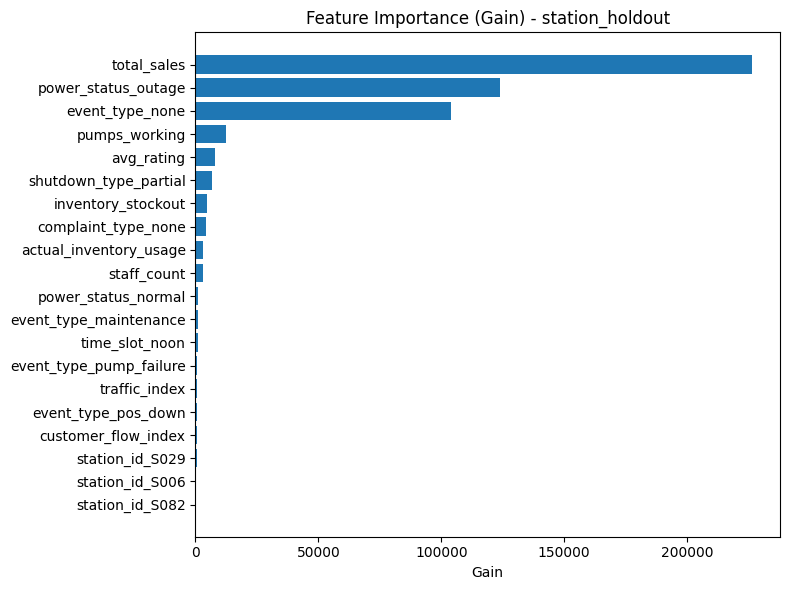

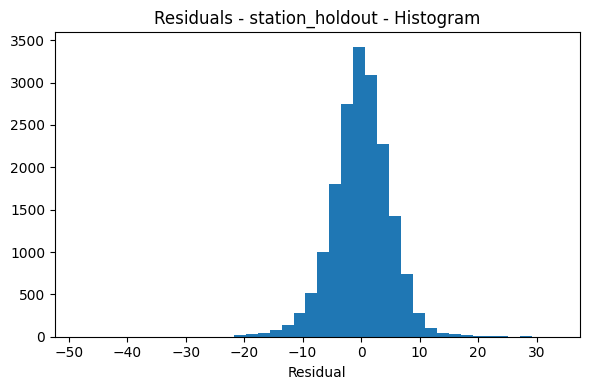

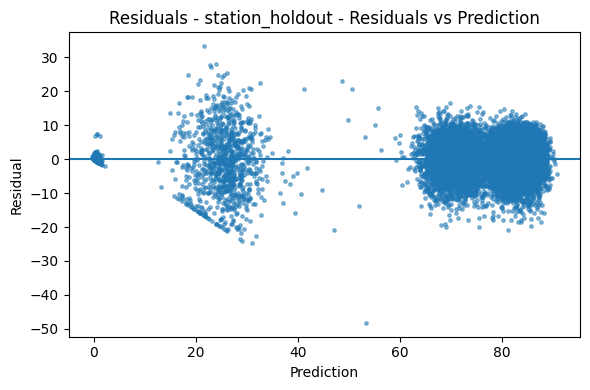

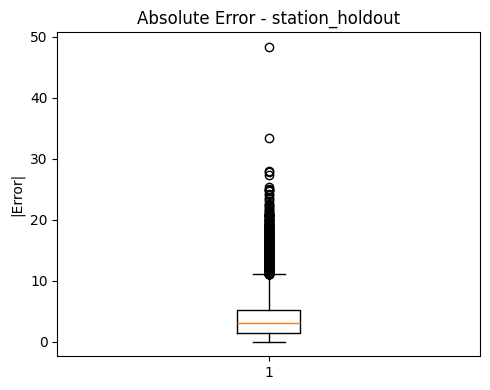

,station_id,city,station_type,area_m2,competitors_within_3km,nearby_services_density,has_convenience_store,has_cafe,has_atm,has_car_wash,...,inventory_stockout,inventory_days_of_cover,actual_inventory_usage,performance_score,day_of_week,customer_flow_index,performance_score_obs,_y_true,_y_pred,_abs_err
67524,S085,Makkah,Urban,1828,5,5.32,0,1,1,0,...,0,4.1,138.70,23.943232,2,0.61,5.0,5.0,53.276299,48.276299
70218,S085,Makkah,Urban,1828,5,5.32,0,1,1,0,...,0,1.9,181.10,27.853195,0,0.73,55.0,55.0,21.665396,33.334604
19162,S017,Madinah,Neighborhood,1395,2,4.06,1,1,0,0,...,0,5.0,181.25,30.281698,0,0.77,51.9,51.9,23.863695,28.036305
80869,S041,Dammam,Urban,1252,4,7.99,1,0,1,0,...,0,0.0,83.23,29.182631,2,0.62,50.6,50.6,22.838346,27.761654
56594,S036,Taif,Urban,2314,5,4.24,1,0,1,1,...,0,4.5,371.63,26.016902,4,0.83,50.3,50.3,23.025217,27.274783
77951,S074,Najran,Neighborhood,1197,3,3.19,1,0,0,0,...,0,3.8,293.09,35.279631,4,1.02,51.4,51.4,26.042732,25.357268
66525,S053,Jeddah,Urban,2020,10,3.72,1,0,1,0,...,0,8.1,266.86,33.408102,6,0.62,50.4,50.4,25.439348,24.960652
86928,S041,Dammam,Urban,1252,4,7.99,1,0,1,0,...,0,7.8,132.62,25.939186,3,0.86,43.3,43.3,18.377901,24.922099
35284,S085,Makkah,Urban,1828,5,5.32,0,1,1,0,...,0,5.3,204.82,34.290882,0,0.81,49.1,49.1,24.297211,24.802789
2419,S057,Najran,Neighborhood,1652,7,4.15,1,1,1,0,...,0,5.4,64.42,27.714714,1,0.59,6.3,6.3,30.985432,24.685432


/tmp/ipython-input-1236/3234116053.py:114: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, show=False)


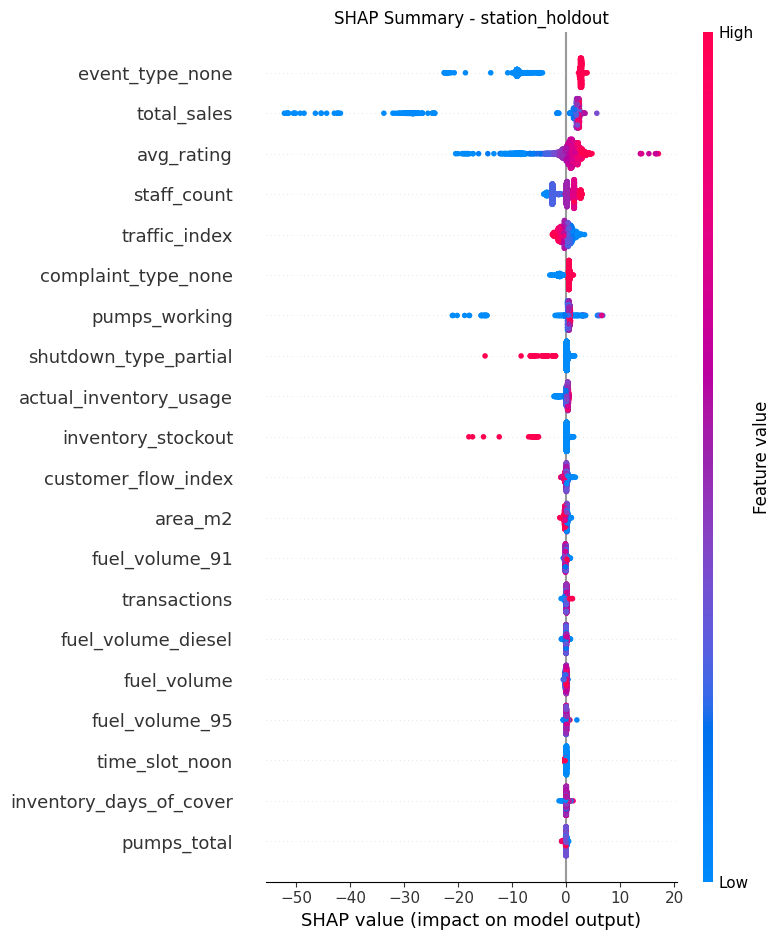

Saved: /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/station_holdout/xgb_station_holdout.json
Saved: /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/station_holdout/feature_cols_station_holdout.pkl
Saved: /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/station_holdout/global_drivers_top10_station_holdout.json
Saved: /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/station_holdout/surrogate_station_holdout.pkl
Saved: /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/station_holdout/surrogate_rules_station_holdout.txt
Saved: /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/station_holdout/dashboard_predictions_station_holdout.csv


In [ ]:
# ============================================
# (Cell 10.3) Train/Eval + Export: Station Holdout
# ============================================
model_station, X_train_station, X_test_station, y_train_station, y_test_station, y_pred_station, out_station, drivers_station = \
    train_eval_and_export("station_holdout", train_df_station, test_df_station, do_shap=True)

In [ ]:
# ============================================
# (Cell 10.4) Split 2: Year Holdout (Train 2024 -> Test 2025)
# ============================================
if "year" not in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df["year"] = df["date"].dt.year

train_df_year = df[df["year"] == 2024].copy()
test_df_year  = df[df["year"] == 2025].copy()

print("SPLIT: YEAR_HOLDOUT")
print("Train rows:", len(train_df_year), "| Test rows:", len(test_df_year))
print("Train stations:", train_df_year["station_id"].nunique(), "| Test stations:", test_df_year["station_id"].nunique())

SPLIT: YEAR_HOLDOUT
Train rows: 45063 | Test rows: 44937
Train stations: 45 | Test stations: 45



=== RUN: year_holdout ===
Train rows: 45063 | Test rows: 44937
X_train shape: (45063, 119)
X_test shape: (44937, 119)


,Split,MAE,RMSE,R2,Mean Residual,Median |Residual|,% |Error| > 10,Train Size,Test Size,Features
0,year_holdout,3.7497,4.9518,0.9161,0.0148,2.985,4.58,45063,44937,119


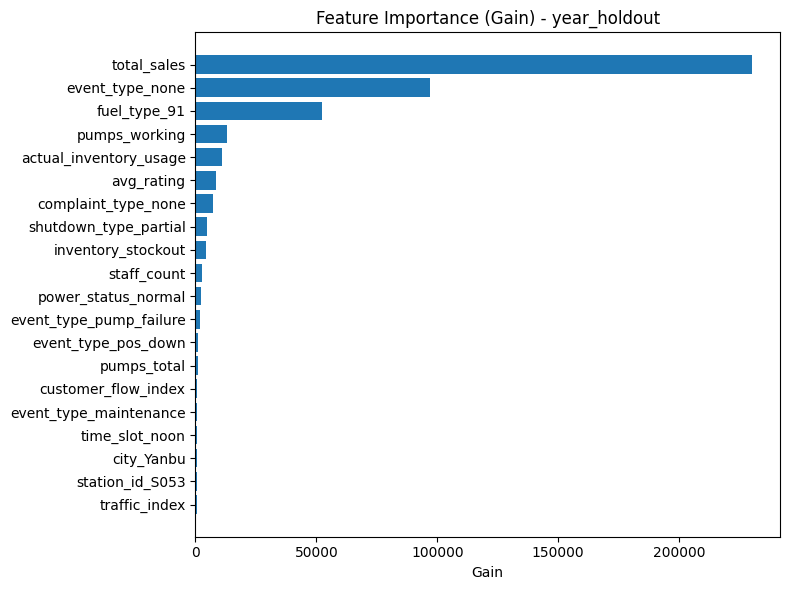

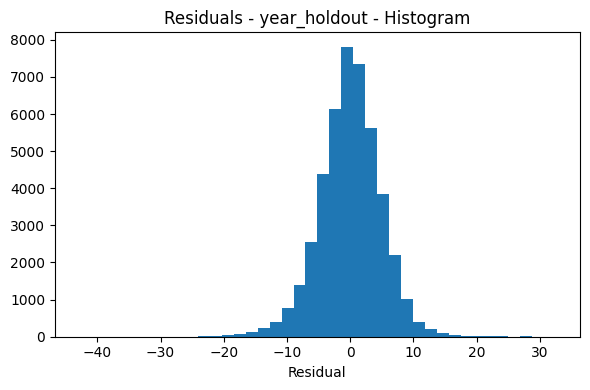

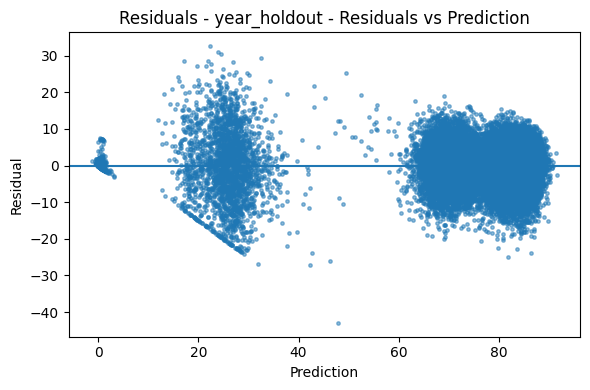

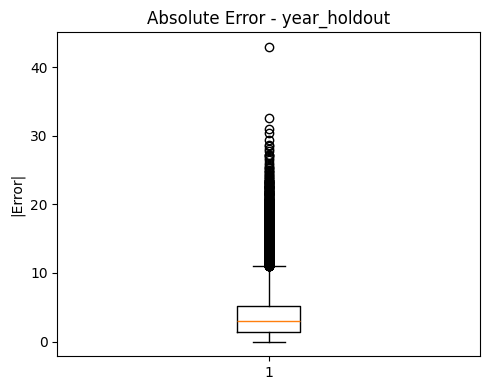

,station_id,city,station_type,area_m2,competitors_within_3km,nearby_services_density,has_convenience_store,has_cafe,has_atm,has_car_wash,...,inventory_stockout,inventory_days_of_cover,actual_inventory_usage,performance_score,day_of_week,customer_flow_index,performance_score_obs,_y_true,_y_pred,_abs_err
67524,S085,Makkah,Urban,1828,5,5.32,0,1,1,0,...,0,4.1,138.700000,23.943232,2,0.61,5.0,5.0,47.945030,42.945030
71359,S073,Madinah,Urban,2626,7,5.02,0,1,1,1,...,0,6.6,181.670000,22.414221,0,0.67,55.0,55.0,22.430470,32.569530
87939,S078,Yanbu,Urban,1820,3,6.33,1,1,1,0,...,0,5.3,206.810000,34.638366,5,1.01,55.0,55.0,23.950274,31.049726
70218,S085,Makkah,Urban,1828,5,5.32,0,1,1,0,...,0,1.9,181.100000,27.853195,0,0.73,55.0,55.0,24.515800,30.484200
66812,S041,Dammam,Urban,1252,4,7.99,1,0,1,0,...,0,1.1,519.920000,55.216393,1,0.91,61.9,61.9,32.452183,29.447817
80869,S041,Dammam,Urban,1252,4,7.99,1,0,1,0,...,0,0.0,83.230000,29.182631,2,0.62,50.6,50.6,21.995043,28.604957
3744,S078,Yanbu,Urban,1820,3,6.33,1,1,1,0,...,1,0.0,116.731980,16.374012,5,0.65,45.6,45.6,17.098251,28.501749
59853,S014,Dammam,Highway,1697,2,5.91,0,1,0,0,...,0,2.7,227.750000,35.264677,4,0.75,55.0,55.0,26.884701,28.115299
56594,S036,Taif,Urban,2314,5,4.24,1,0,1,1,...,0,4.5,371.630000,26.016902,4,0.83,50.3,50.3,22.496561,27.803439
4195,S016,Madinah,Neighborhood,1189,7,4.62,1,1,1,0,...,0,4.5,242.700000,22.875923,4,0.87,15.1,15.1,42.362671,27.262671


/tmp/ipython-input-1236/3234116053.py:114: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, show=False)


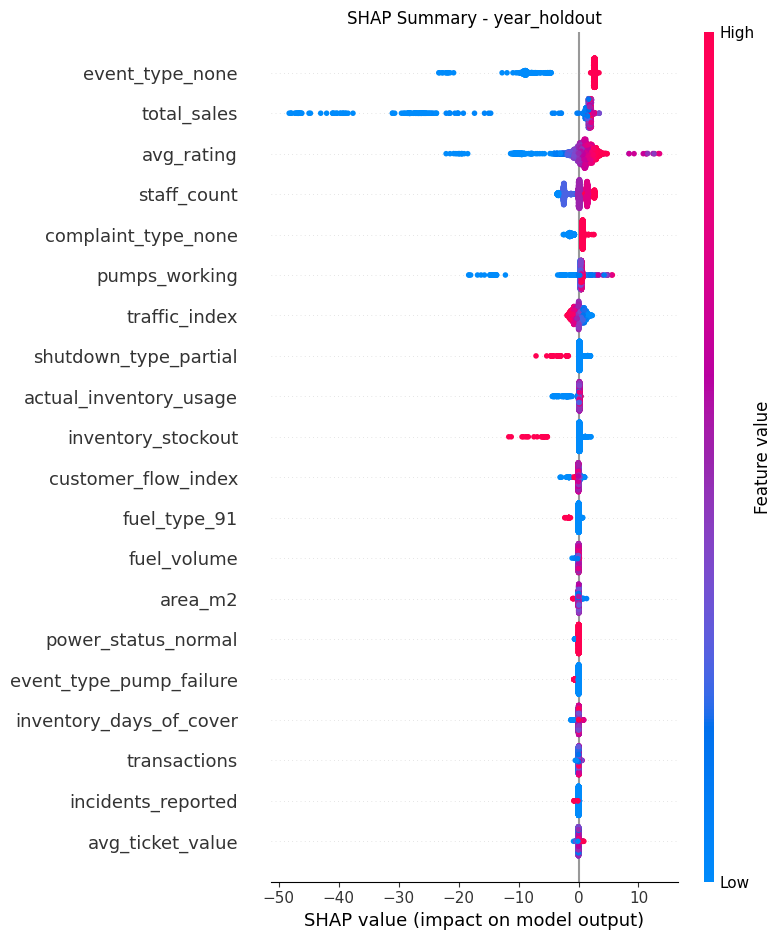

Saved: /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/year_holdout/xgb_year_holdout.json
Saved: /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/year_holdout/feature_cols_year_holdout.pkl
Saved: /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/year_holdout/global_drivers_top10_year_holdout.json
Saved: /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/year_holdout/surrogate_year_holdout.pkl
Saved: /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/year_holdout/surrogate_rules_year_holdout.txt
Saved: /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/year_holdout/dashboard_predictions_year_holdout.csv


In [ ]:
# ============================================
# (Cell 10.5) Train/Eval + Export: Year Holdout
# ============================================
model_year, X_train_year, X_test_year, y_train_year, y_test_year, y_pred_year, out_year, drivers_year = \
    train_eval_and_export("year_holdout", train_df_year, test_df_year, do_shap=True)

In [ ]:
# ============================================
# (Cell 10.6) Split 3: Station + Time Combined Holdout
# ============================================
SEED = 42
rng = np.random.default_rng(SEED)

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["station_id"] = df["station_id"].astype(str)

stations = df["station_id"].unique()
rng.shuffle(stations)

n_test = max(1, int(len(stations) * 0.20))
test_stations = set(stations[:n_test])

start_date = pd.Timestamp("2025-10-01")
end_date   = pd.Timestamp("2025-12-31")

time_mask    = (df["date"] >= start_date) & (df["date"] <= end_date)
station_mask = df["station_id"].isin(test_stations)

test_mask = station_mask & time_mask

train_df_station_time = df.loc[~test_mask].copy()
test_df_station_time  = df.loc[test_mask].copy()

print("SPLIT: STATION_TIME_HOLDOUT")
print("Test stations:", len(test_stations))
print("Time window:", start_date.date(), "to", end_date.date())
print("Train rows:", len(train_df_station_time), "| Test rows:", len(test_df_station_time))
print("Train stations:", train_df_station_time["station_id"].nunique(), "| Test stations in test:", test_df_station_time["station_id"].nunique())

assert len(test_df_station_time) > 0, "Test set is empty. Change time window or station fraction."

SPLIT: STATION_TIME_HOLDOUT
Test stations: 9
Time window: 2025-10-01 to 2025-12-31
Train rows: 87741 | Test rows: 2259
Train stations: 45 | Test stations in test: 9



=== RUN: station_time_holdout ===
Train rows: 87741 | Test rows: 2259
X_train shape: (87741, 119)
X_test shape: (2259, 119)


,Split,MAE,RMSE,R2,Mean Residual,Median |Residual|,% |Error| > 10,Train Size,Test Size,Features
0,station_time_holdout,3.8087,5.065,0.9175,-0.0775,3.0134,4.96,87741,2259,119


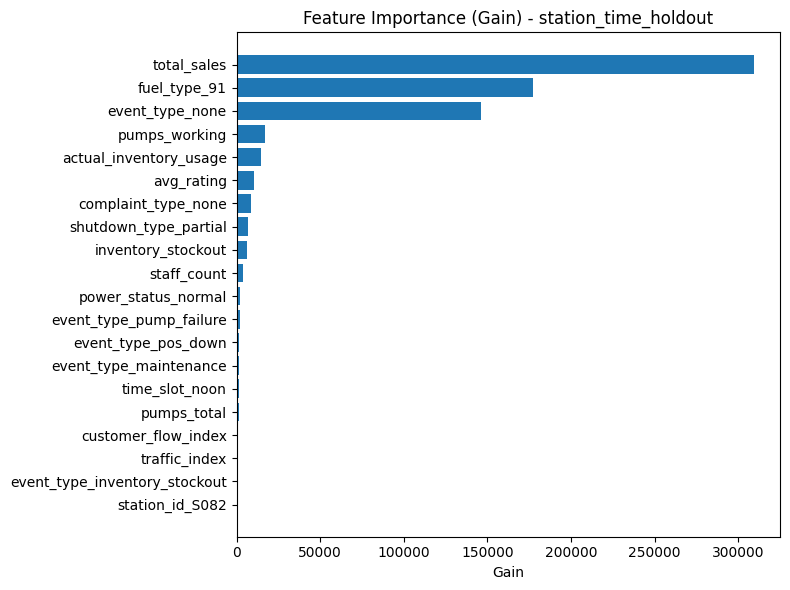

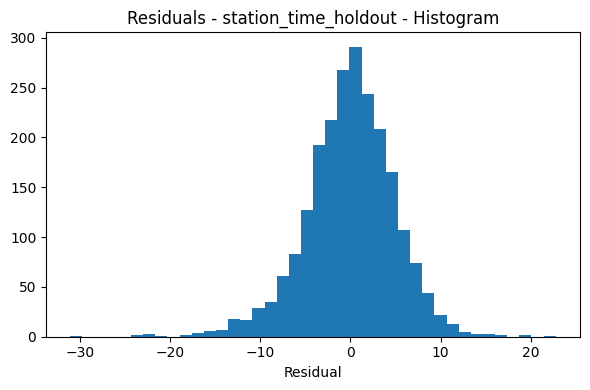

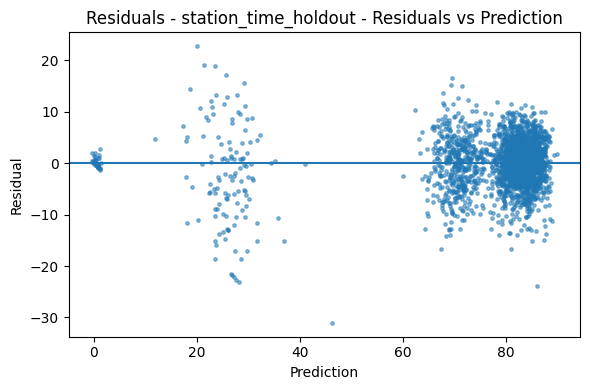

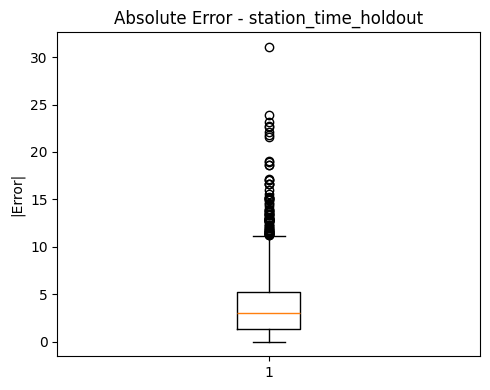

,station_id,city,station_type,area_m2,competitors_within_3km,nearby_services_density,has_convenience_store,has_cafe,has_atm,has_car_wash,...,inventory_stockout,inventory_days_of_cover,actual_inventory_usage,performance_score,day_of_week,customer_flow_index,performance_score_obs,_y_true,_y_pred,_abs_err
4195,S016,Madinah,Neighborhood,1189,7,4.62,1,1,1,0,...,0,4.5,242.700000,22.875923,4,0.87,15.1,15.1,46.165806,31.065806
50218,S065,Hail,Neighborhood,1789,6,6.17,0,0,1,1,...,0,3.4,1229.560000,63.786059,1,1.13,62.3,62.3,86.154449,23.854449
75039,S009,Dammam,Highway,1745,2,2.09,0,0,0,0,...,0,6.4,187.390000,18.277127,6,0.82,5.0,5.0,28.132574,23.132574
33940,S082,Riyadh,Urban,1926,5,6.74,1,0,1,1,...,1,0.0,235.807396,18.480536,5,0.91,42.7,42.7,19.929787,22.770213
29597,S082,Riyadh,Urban,1926,5,6.74,1,0,1,1,...,0,5.5,258.700000,18.346190,6,0.86,5.0,5.0,27.649643,22.649643
42229,S017,Madinah,Neighborhood,1395,2,4.06,1,1,0,0,...,0,7.3,119.490000,24.786605,6,0.62,5.0,5.0,27.130978,22.130978
7815,S067,Jeddah,Highway,2230,2,1.63,1,0,1,1,...,0,3.4,486.280000,21.679075,3,0.91,5.0,5.0,26.790220,21.790220
20516,S049,Jeddah,Urban,1074,4,4.59,1,1,1,0,...,0,1.4,136.710000,19.018959,6,0.64,5.0,5.0,26.617846,21.617846
13935,S049,Jeddah,Urban,1074,4,4.59,1,1,1,0,...,0,0.9,149.530000,26.104998,2,0.81,40.4,40.4,21.343077,19.056923
15673,S054,Riyadh,Neighborhood,2292,6,5.46,1,1,1,0,...,0,2.6,637.870000,31.309072,5,0.81,42.5,42.5,23.586233,18.913767


/tmp/ipython-input-1236/3234116053.py:114: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, show=False)


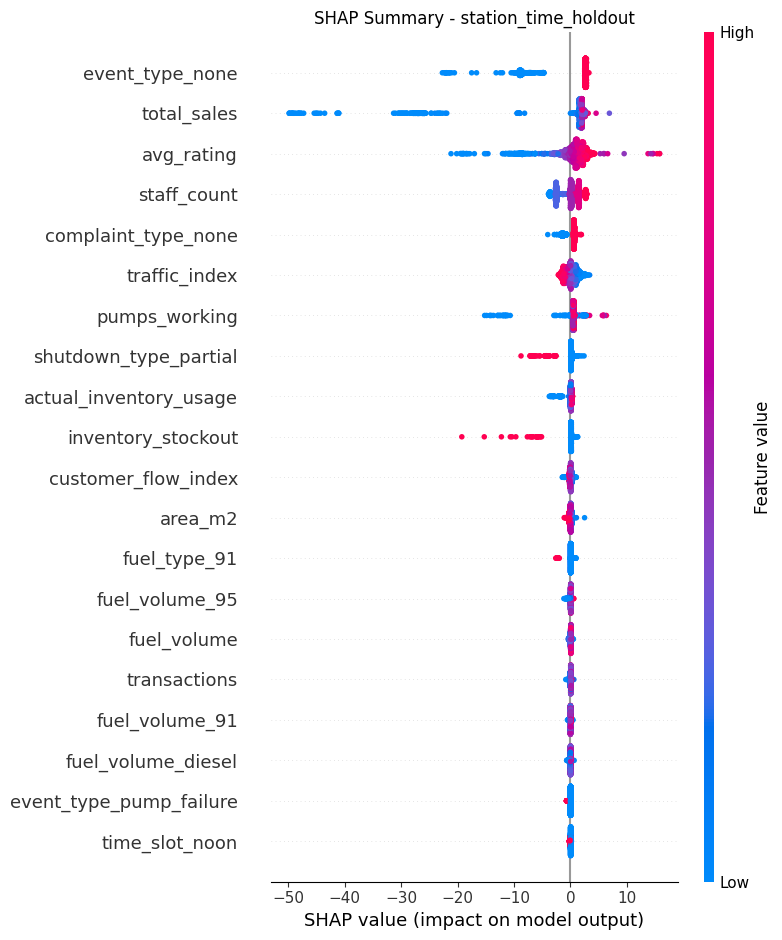

Saved: /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/station_time_holdout/xgb_station_time_holdout.json
Saved: /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/station_time_holdout/feature_cols_station_time_holdout.pkl
Saved: /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/station_time_holdout/global_drivers_top10_station_time_holdout.json
Saved: /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/station_time_holdout/surrogate_station_time_holdout.pkl
Saved: /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/station_time_holdout/surrogate_rules_station_time_holdout.txt
Saved: /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/station_time_holdout/dashboard_predictions_station_time_holdout.csv


In [ ]:
# ============================================
# (Cell 10.7) Train/Eval + Export: Station + Time Holdout
# ============================================
model_station_time, X_train_station_time, X_test_station_time, y_train_station_time, y_test_station_time, y_pred_station_time, out_station_time, drivers_station_time = \
    train_eval_and_export("station_time_holdout", train_df_station_time, test_df_station_time, do_shap=True)

In [ ]:
# ============================================
# (Cell 10.8) Split 4: City Holdout (one unseen city)
# ============================================
assert "city" in df.columns, "Missing column: city"

df["city"] = df["city"].astype(str).str.strip()
df.loc[df["city"].isin(["", "nan", "None"]), "city"] = np.nan

valid_cities = df["city"].dropna().unique()
assert len(valid_cities) > 1, "Need at least 2 valid cities for holdout."

rng = np.random.default_rng(SEED)
holdout_city = rng.choice(valid_cities)

train_df_city = df[df["city"] != holdout_city].copy()
test_df_city  = df[df["city"] == holdout_city].copy()

print("SPLIT: CITY_HOLDOUT")
print("Holdout city:", holdout_city)
print("Train rows:", len(train_df_city), "| Test rows:", len(test_df_city))
print("Train cities:", train_df_city["city"].nunique(), "| Test cities:", test_df_city["city"].nunique())
print("Train stations:", train_df_city["station_id"].nunique(), "| Test stations:", test_df_city["station_id"].nunique())

assert len(test_df_city) > 0, "Test set is empty. Pick a different holdout city."

SPLIT: CITY_HOLDOUT
Holdout city: Buraydah
Train rows: 88047 | Test rows: 1953
Train cities: 11 | Test cities: 1
Train stations: 44 | Test stations: 1



=== RUN: city_holdout ===
Train rows: 88047 | Test rows: 1953
X_train shape: (88047, 117)
X_test shape: (1953, 117)


,Split,MAE,RMSE,R2,Mean Residual,Median |Residual|,% |Error| > 10,Train Size,Test Size,Features
0,city_holdout,3.7502,5.0033,0.9013,-0.1302,2.9254,5.33,88047,1953,117


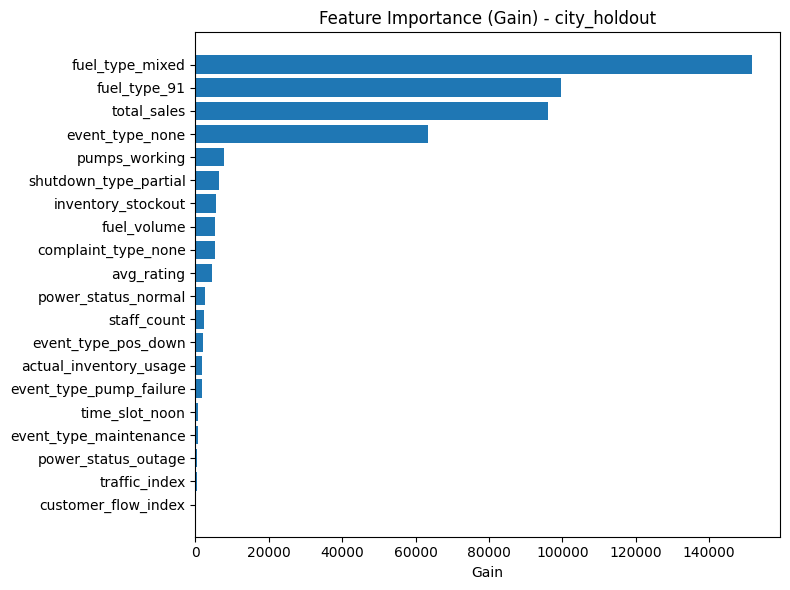

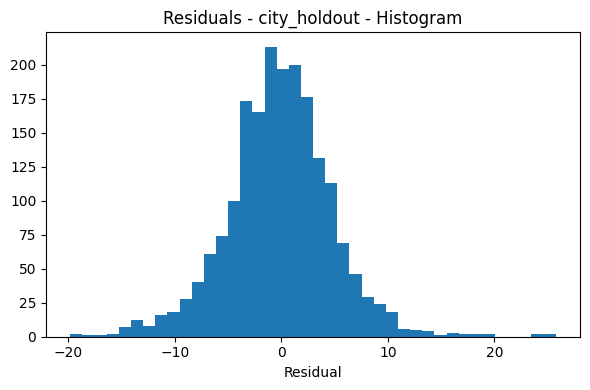

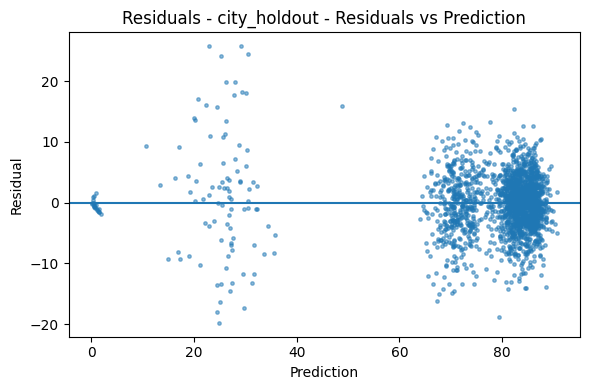

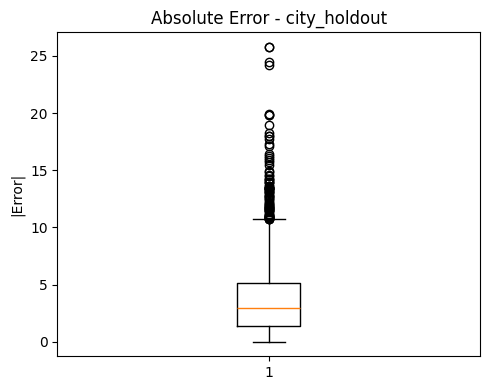

,station_id,city,station_type,area_m2,competitors_within_3km,nearby_services_density,has_convenience_store,has_cafe,has_atm,has_car_wash,...,inventory_stockout,inventory_days_of_cover,actual_inventory_usage,performance_score,day_of_week,customer_flow_index,performance_score_obs,_y_true,_y_pred,_abs_err
17415,S060,Buraydah,Urban,1564,7,3.16,1,0,1,1,...,0,4.9,270.600000,43.650113,2,0.76,55.0,55.0,29.231627,25.768373
80455,S060,Buraydah,Urban,1564,7,3.16,1,0,1,1,...,1,0.0,81.293986,13.575562,3,0.66,48.6,48.6,22.850271,25.749729
82808,S060,Buraydah,Urban,1564,7,3.16,1,0,1,1,...,0,3.3,119.650000,36.383099,3,0.66,55.0,55.0,30.517580,24.482420
86256,S060,Buraydah,Urban,1564,7,3.16,1,0,1,1,...,0,5.3,331.840000,21.617528,6,0.84,49.4,49.4,25.226437,24.173563
76230,S060,Buraydah,Urban,1564,7,3.16,1,0,1,1,...,0,4.1,328.480000,43.478765,2,0.87,48.0,48.0,28.056129,19.943871
28015,S060,Buraydah,Urban,1564,7,3.16,1,0,1,1,...,0,6.9,105.600000,31.388693,4,0.81,46.0,46.0,26.159330,19.840670
59298,S060,Buraydah,Urban,1564,7,3.16,1,0,1,1,...,0,5.3,139.130000,24.155372,4,0.87,5.0,5.0,24.800802,19.800802
38734,S060,Buraydah,Urban,1564,7,3.16,1,0,1,1,...,0,4.8,884.370000,60.989433,4,1.10,60.4,60.4,79.313660,18.913660
19990,S060,Buraydah,Urban,1564,7,3.16,1,0,1,1,...,0,5.6,138.580000,35.882357,4,0.70,47.7,47.7,29.453516,18.246484
25029,S060,Buraydah,Urban,1564,7,3.16,1,0,1,1,...,0,1.4,161.860000,22.894118,3,0.85,6.5,6.5,24.510847,18.010847


/tmp/ipython-input-1236/3234116053.py:114: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, show=False)


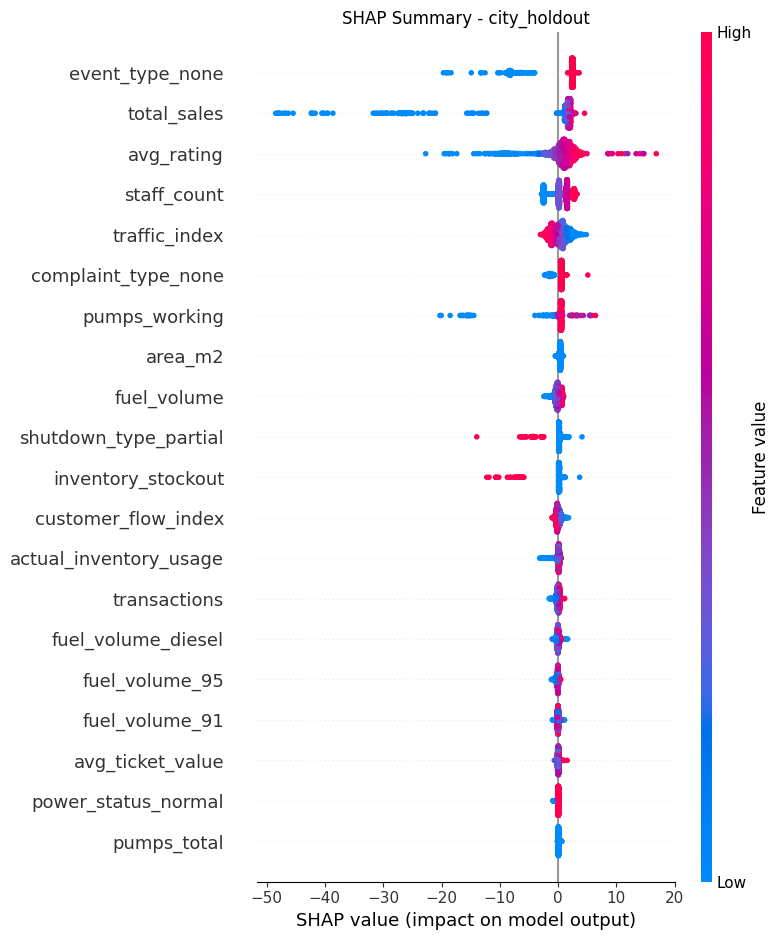

Saved: /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/city_holdout/xgb_city_holdout.json
Saved: /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/city_holdout/feature_cols_city_holdout.pkl
Saved: /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/city_holdout/global_drivers_top10_city_holdout.json
Saved: /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/city_holdout/surrogate_city_holdout.pkl
Saved: /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/city_holdout/surrogate_rules_city_holdout.txt
Saved: /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/city_holdout/dashboard_predictions_city_holdout.csv


In [ ]:
# ============================================
# (Cell 10.9) Train/Eval + Export: City Holdout
# ============================================
model_city, X_train_city, X_test_city, y_train_city, y_test_city, y_pred_city, out_city, drivers_city = \
    train_eval_and_export("city_holdout", train_df_city, test_df_city, do_shap=True, name_suffix=holdout_city)

In [ ]:
# ============================================
# (Cell 10.10) Final: 4-split comparison table (FIX)
# ============================================
# all_summaries is list of dicts
comparison_df = pd.DataFrame(all_summaries)

# Keep latest run per split
comparison_df_4 = (
    comparison_df
    .drop_duplicates(subset=["Split"], keep="last")
    .reset_index(drop=True)
)

# Optional: keep only the 4 desired splits (if duplicates happened قبل)
keep_prefix = ["station_holdout", "year_holdout", "station_time_holdout", "city_holdout"]
comparison_df_4 = comparison_df_4[
    comparison_df_4["Split"].astype(str).apply(lambda s: any(s.startswith(k) for k in keep_prefix))
].reset_index(drop=True)

display(comparison_df_4)
print("len(all_summaries) =", len(all_summaries))
print("unique splits =", comparison_df_4["Split"].nunique())

# Save comparison table
comparison_path = os.path.join(EXPORT_ROOT, "comparison_splits_4.csv")
comparison_df_4.to_csv(comparison_path, index=False)

print("Saved:", comparison_path)

,Split,MAE,RMSE,R2,Mean Residual,Median |Residual|,% |Error| > 10,Train Size,Test Size,Features
0,station_holdout,3.7255,4.9124,0.9169,-0.0085,2.9629,4.43,71883,18117,108
1,year_holdout,3.7497,4.9518,0.9161,0.0148,2.9850,4.58,45063,44937,119
2,station_time_holdout,3.8087,5.0650,0.9175,-0.0775,3.0134,4.96,87741,2259,119
3,city_holdout,3.7502,5.0033,0.9013,-0.1302,2.9254,5.33,88047,1953,117


len(all_summaries) = 4
unique splits = 4
Saved: /content/drive/MyDrive/Dataset/Model1_Results/step10_exports/comparison_splits_4.csv


# Appendix A — Performance Segmentation Analysis

In [ ]:
low_df = df[df["performance_score_obs"] < 40]
normal_df = df[df["performance_score_obs"] >= 40]

cols_to_check = [
    "downtime_minutes",
    "complaints_count",
    "event_severity",
    "queue_time_avg"
]

comparison = pd.DataFrame({
    "low_performance_mean": low_df[cols_to_check].mean(),
    "normal_performance_mean": normal_df[cols_to_check].mean()
})

print(comparison)

                  low_performance_mean  normal_performance_mean
downtime_minutes            154.145941                 8.366835
complaints_count              3.176093                 0.289555
event_severity                2.974665                 0.356490
queue_time_avg                8.645021                 4.443538


# Appendix B — Split Sensitivity (Station vs City) using SHAP

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb

def shap_from_xgb(model, X, feature_cols):
    # Force same columns + same order as training
    X_aligned = X.reindex(columns=feature_cols, fill_value=0)

    dmat = xgb.DMatrix(X_aligned, feature_names=list(feature_cols))
    contrib = model.predict(dmat, pred_contribs=True)  # (n, num_features+1)
    shap_vals = contrib[:, :-1]  # drop bias
    return shap_vals, X_aligned.columns

# 1) Get each model’s training feature columns
cols_station = X_train_station.columns
cols_city    = X_train_city.columns

# 2) Compute SHAP values using XGBoost native contributions
shap_station, feat_station = shap_from_xgb(model_station, X_test_station, cols_station)
shap_city, feat_city       = shap_from_xgb(model_city, X_test_city, cols_city)

# 3) Compare on union of features (fair + no mismatch)
all_feats = feat_station.union(feat_city)

station_mean = pd.Series(np.abs(shap_station).mean(axis=0), index=feat_station).reindex(all_feats, fill_value=0)
city_mean    = pd.Series(np.abs(shap_city).mean(axis=0), index=feat_city).reindex(all_feats, fill_value=0)

comparison_df = pd.DataFrame({
    "feature": all_feats,
    "station_importance": station_mean.values,
    "city_importance": city_mean.values
})

comparison_df["difference_city_minus_station"] = comparison_df["city_importance"] - comparison_df["station_importance"]
comparison_df = comparison_df.sort_values("difference_city_minus_station", ascending=False)

print(comparison_df.head(15))

                    feature  station_importance  city_importance  \
34          event_type_none            0.160512         4.027193   
123             total_sales            0.049581         3.346088   
124           traffic_index            0.031143         1.125193   
2                avg_rating            0.926325         1.982928   
19      complaint_type_none            0.085490         0.828530   
43              fuel_volume            0.038311         0.392481   
69    shutdown_type_partial            0.000321         0.353359   
1                   area_m2            0.048355         0.376284   
66            pumps_working            0.356549         0.667990   
24      customer_flow_index            0.034688         0.268616   
0    actual_inventory_usage            0.021241         0.228728   
70              staff_count            1.266821         1.433482   
125            transactions            0.045762         0.196246   
46       fuel_volume_diesel            0.034460 

# Appendix C — Residual Extreme Case Analysis

In [ ]:
# Residual Outlier Analysis

dtest = xgb.DMatrix(X_test)
y_pred = model_city.predict(dtest)

residuals = y_test - y_pred
abs_residuals = np.abs(residuals)

threshold = np.percentile(abs_residuals, 95)

outliers_mask = abs_residuals >= threshold

outliers_df = test_df.iloc[outliers_mask]

print("Number of extreme error cases:", len(outliers_df))
print(outliers_df.head())

Number of extreme error cases: 98
     station_id      city station_type  area_m2  competitors_within_3km  \
504        S060  Buraydah        Urban     1564                       7   
2478       S060  Buraydah        Urban     1564                       7   
4767       S060  Buraydah        Urban     1564                       7   
5099       S060  Buraydah        Urban     1564                       7   
5887       S060  Buraydah        Urban     1564                       7   

      nearby_services_density  has_convenience_store  has_cafe  has_atm  \
504                      3.16                      1         0        1   
2478                     3.16                      1         0        1   
4767                     3.16                      1         0        1   
5099                     3.16                      1         0        1   
5887                     3.16                      1         0        1   

      has_car_wash  ... complaints_count    complaint_type  avg_

# Appendix D — Model Sanity Checks (Leakage Validation Experiments)


## Permutation Test

In [ ]:
# # Sanity Check 1: Permutation Test (shuffle target)

# import numpy as np
# import xgboost as xgb
# from sklearn.metrics import r2_score

# # Shuffle training target
# y_train_perm = np.random.permutation(y_train)

# dtrain_perm = xgb.DMatrix(X_train, label=y_train_perm)
# dtest_perm  = xgb.DMatrix(X_test, label=y_test)

# model_perm = xgb.train(
#     params,
#     dtrain_perm,
#     num_boost_round=2000,
#     evals=[(dtest_perm, "test")],
#     early_stopping_rounds=100,
#     verbose_eval=False
# )

# y_pred_perm = model_perm.predict(dtest_perm)

# r2_perm = r2_score(y_test, y_pred_perm)

# print("Permutation Test R2:", round(r2_perm, 4))

## Remove Strong Predictors Test

In [ ]:
# # Sanity Check 2: Drop strong revenue-related features

# drop_strong = [
#     "total_sales",
#     "transactions",
#     "fuel_volume",
#     "fuel_volume_91",
#     "fuel_volume_95",
#     "fuel_volume_diesel",
# ]

# X_train_reduced = X_train.drop(columns=[c for c in drop_strong if c in X_train.columns])
# X_test_reduced  = X_test.drop(columns=[c for c in drop_strong if c in X_test.columns])

# dtrain_red = xgb.DMatrix(X_train_reduced, label=y_train)
# dtest_red  = xgb.DMatrix(X_test_reduced, label=y_test)

# model_red = xgb.train(
#     params,
#     dtrain_red,
#     num_boost_round=2000,
#     evals=[(dtest_red, "test")],
#     early_stopping_rounds=100,
#     verbose_eval=False
# )

# y_pred_red = model_red.predict(dtest_red)

# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# mae_red = mean_absolute_error(y_test, y_pred_red)
# rmse_red = np.sqrt(mean_squared_error(y_test, y_pred_red))
# r2_red = r2_score(y_test, y_pred_red)

# print("Reduced Features -> MAE:", round(mae_red, 3))
# print("Reduced Features -> RMSE:", round(rmse_red, 3))
# print("Reduced Features -> R2:", round(r2_red, 3))